In [14]:
# ============================================================
# SECTION 1: PROJECT OVERVIEW
# ============================================================

"""
Project:
Multi-Agent AI Framework for Fossil Fuel Displacement

Agent:
Emission Monitoring Agent

Goal:
Compare India-only training vs South Asia regional training for India's CO2 forecasting.

Countries:
India, Pakistan, Bangladesh, Sri Lanka, Nepal

Target:
co2

Research Question:
Does regional South Asia knowledge improve India's CO2 emission forecasting?

Important:
CO2-derived leakage columns are removed from training.
Temperature-change variables are excluded from prediction features.
Country is encoded using one-hot encoding.
"""

"\nProject:\nMulti-Agent AI Framework for Fossil Fuel Displacement\n\nAgent:\nEmission Monitoring Agent\n\nGoal:\nCompare India-only training vs South Asia regional training for India's CO2 forecasting.\n\nCountries:\nIndia, Pakistan, Bangladesh, Sri Lanka, Nepal\n\nTarget:\nco2\n\nResearch Question:\nDoes regional South Asia knowledge improve India's CO2 emission forecasting?\n\nImportant:\nCO2-derived leakage columns are removed from training.\nTemperature-change variables are excluded from prediction features.\nCountry is encoded using one-hot encoding.\n"

In [15]:
# ============================================================
# SECTION 2: IMPORTS AND CONFIGURATION
# ============================================================

import os
import json
import time
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
import xgboost

from scipy import stats
from matplotlib.backends.backend_pdf import PdfPages

from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, GridSearchCV, cross_val_score, learning_curve
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import mutual_info_regression, RFE
from sklearn.inspection import permutation_importance

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, VotingRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

RANDOM_STATE = 42
MIN_YEAR = 1950
N_SPLITS = 5
TRAIN_SIZE = 0.70
VAL_SIZE = 0.15

ENABLE_SHAP = True
ENABLE_LEARNING_CURVE = True

DATASET_PATH = r"E:\Multi_agentic_AI_Project\Dataset\owid-co2-data.csv"

COUNTRIES = ["India", "Pakistan", "Bangladesh", "Sri Lanka", "Nepal"]

LEAKAGE_COLUMNS = [
    "coal_co2", "oil_co2", "gas_co2", "cement_co2", "flaring_co2",
    "total_ghg", "total_ghg_excluding_lucf",
    "co2_per_capita", "co2_growth_abs", "co2_growth_prct",
    "co2_including_luc", "co2_including_luc_growth_abs",
    "co2_including_luc_growth_prct", "share_global_co2",
    "cumulative_co2", "consumption_co2", "trade_co2",
    "carbon_intensity"
]

TEMPERATURE_COLUMNS = [
    "temperature_change_from_ch4",
    "temperature_change_from_co2",
    "temperature_change_from_ghg",
    "temperature_change_from_n2o"
]

In [16]:
# ============================================================
# SECTION 3: UTILITY FUNCTIONS
# ============================================================

def clean_column_names(df):
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.replace(" ", "_", regex=False)
        .str.replace("-", "_", regex=False)
        .str.replace("/", "_", regex=False)
    )
    return df


def safe_divide(a, b):
    return a / (b + 1e-9)


def safe_mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0

    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def find_existing_columns(df, columns):
    return [col for col in columns if col in df.columns]


def save_current_plot(filename):
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


def chronological_split_df(df, train_size=0.70, val_size=0.15):
    df = df.sort_values("year").reset_index(drop=True)

    n = len(df)
    train_end = int(n * train_size)
    val_end = int(n * (train_size + val_size))

    return (
        df.iloc[:train_end].copy(),
        df.iloc[train_end:val_end].copy(),
        df.iloc[val_end:].copy()
    )


def split_by_country(df, countries):
    train_parts, val_parts, test_parts = [], [], []

    for country in countries:
        cdf = df[df["country"] == country].copy()
        train_df, val_df, test_df = chronological_split_df(cdf)

        train_parts.append(train_df)
        val_parts.append(val_df)
        test_parts.append(test_df)

    train_df = pd.concat(train_parts).sort_values(["year", "country"]).reset_index(drop=True)
    val_df = pd.concat(val_parts).sort_values(["year", "country"]).reset_index(drop=True)
    test_df = pd.concat(test_parts).sort_values(["year", "country"]).reset_index(drop=True)

    return train_df, val_df, test_df


def get_emission_level(predicted_co2, historical_series):
    low_threshold = historical_series.quantile(0.33)
    high_threshold = historical_series.quantile(0.66)

    if predicted_co2 <= low_threshold:
        return "low"
    elif predicted_co2 <= high_threshold:
        return "medium"
    return "high"


def get_recommended_action(emission_level):
    if emission_level == "low":
        return "Maintain Renewable Growth"
    elif emission_level == "medium":
        return "Increase Renewable Usage"
    return "Reduce Fossil Fuel Usage"

In [17]:
# ============================================================
# SECTION 4: TIME-SERIES-SAFE STACKING MODEL
# ============================================================

class TimeSeriesStackingRegressor(BaseEstimator, RegressorMixin):
    """
    Time-series-aware stacking regressor.

    Why custom?
    sklearn StackingRegressor internally uses cross_val_predict.
    TimeSeriesSplit does not always create full test partitions,
    so it can cause partition errors. This custom class creates
    out-of-fold meta-features using TimeSeriesSplit safely.
    """

    def __init__(self, estimators, final_estimator=None, n_splits=5):
        self.estimators = estimators
        self.final_estimator = final_estimator if final_estimator is not None else LinearRegression()
        self.n_splits = n_splits

    def fit(self, X, y):
        X = pd.DataFrame(X).reset_index(drop=True)
        y = pd.Series(y).reset_index(drop=True)

        n_splits = min(self.n_splits, max(2, len(X) // 10))
        tscv = TimeSeriesSplit(n_splits=n_splits)

        meta_X_parts = []
        meta_y_parts = []

        for train_idx, val_idx in tscv.split(X):
            X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

            fold_preds = []

            for name, estimator in self.estimators:
                est = clone(estimator)
                est.fit(X_tr, y_tr)
                fold_preds.append(est.predict(X_val))

            meta_X_parts.append(np.column_stack(fold_preds))
            meta_y_parts.append(y_val.values)

        meta_X = np.vstack(meta_X_parts)
        meta_y = np.concatenate(meta_y_parts)

        self.final_estimator_ = clone(self.final_estimator)
        self.final_estimator_.fit(meta_X, meta_y)

        self.fitted_estimators_ = []

        for name, estimator in self.estimators:
            est = clone(estimator)
            est.fit(X, y)
            self.fitted_estimators_.append((name, est))

        return self

    def predict(self, X):
        X = pd.DataFrame(X)
        meta_X = np.column_stack([
            est.predict(X) for _, est in self.fitted_estimators_
        ])
        return self.final_estimator_.predict(meta_X)

In [18]:
# ============================================================
# SECTION 5: EVALUATION AND FORECAST FUNCTIONS
# ============================================================

def evaluate_model(model, model_name, X_train, y_train, X_val, y_val, X_test, y_test, cv):
    start_train = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start_train

    start_pred = time.time()
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)
    test_pred = model.predict(X_test)
    prediction_time = time.time() - start_pred

    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="r2",
        n_jobs=-1
    )

    metrics = {
        "Model": model_name,
        "Train_R2": r2_score(y_train, train_pred),
        "Validation_R2": r2_score(y_val, val_pred),
        "Test_R2": r2_score(y_test, test_pred),
        "Train_RMSE": np.sqrt(mean_squared_error(y_train, train_pred)),
        "Validation_RMSE": np.sqrt(mean_squared_error(y_val, val_pred)),
        "Test_RMSE": np.sqrt(mean_squared_error(y_test, test_pred)),
        "MAE": mean_absolute_error(y_test, test_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, test_pred)),
        "MAPE": safe_mape(y_test, test_pred),
        "CV_Mean_R2": cv_scores.mean(),
        "CV_Std_R2": cv_scores.std(),
        "Training_Time": training_time,
        "Prediction_Time": prediction_time
    }

    metrics["Overfitting_Gap"] = abs(metrics["Train_R2"] - metrics["Test_R2"])

    return metrics, val_pred, test_pred


def recalculate_engineered_features(row):
    coal = row.get("coal_consumption", 0)
    oil = row.get("oil_consumption", 0)
    gas = row.get("gas_consumption", 0)
    renew = row.get("renewables_consumption", 0)

    fossil = coal + oil + gas
    total = fossil + renew

    row["fossil_dependency_score"] = safe_divide(fossil, total)
    row["renewable_fossil_ratio"] = safe_divide(renew, fossil)

    if "gdp" in row.index and "population" in row.index:
        row["gdp_per_capita"] = safe_divide(row["gdp"], row["population"])

    if "primary_energy_consumption" in row.index and "gdp" in row.index:
        row["energy_intensity"] = safe_divide(row["primary_energy_consumption"], row["gdp"])

    return row


def create_future_forecast(
    model,
    latest_row,
    selected_features,
    residual_std,
    start_year=2025,
    end_year=2030,
    scenario_changes=None
):
    scenario_changes = scenario_changes or {}
    forecasts = []

    previous_row = latest_row.copy()

    for future_year in range(start_year, end_year + 1):
        future_row = previous_row.copy()
        future_row["year"] = future_year

        growth_assumptions = {
            "population": 0.01,
            "gdp": 0.05,
            "primary_energy_consumption": 0.03,
            "renewables_consumption": 0.08,
            "coal_consumption": -0.04,
            "oil_consumption": 0.01,
            "gas_consumption": 0.02,
            "electricity_generation": 0.04
        }

        for feature, growth_rate in growth_assumptions.items():
            if feature in future_row.index:
                future_row[feature] = future_row[feature] * (1 + growth_rate)

        for feature, pct_change in scenario_changes.items():
            if feature in future_row.index:
                future_row[feature] = future_row[feature] * (1 + pct_change)

        future_row = recalculate_engineered_features(future_row)

        if "lag_1" in future_row.index:
            future_row["lag_1"] = previous_row.get("co2", future_row.get("lag_1", 0))
        if "lag_3" in future_row.index:
            future_row["lag_3"] = previous_row.get("lag_1", future_row.get("lag_3", 0))
        if "lag_5" in future_row.index:
            future_row["lag_5"] = previous_row.get("lag_3", future_row.get("lag_5", 0))
        if "lag_10" in future_row.index:
            future_row["lag_10"] = previous_row.get("lag_5", future_row.get("lag_10", 0))

        input_df = pd.DataFrame([future_row[selected_features]])
        prediction = float(model.predict(input_df)[0])

        future_row["co2"] = prediction
        previous_row = future_row.copy()

        forecasts.append({
            "year": future_year,
            "predicted_co2": prediction,
            "lower_bound": prediction - 1.96 * residual_std,
            "upper_bound": prediction + 1.96 * residual_std
        })

    return pd.DataFrame(forecasts)

In [19]:
# ============================================================
# SECTION 6: DATA LOADING AND FILTERING
# ============================================================

raw_df = pd.read_csv(DATASET_PATH)
raw_df = clean_column_names(raw_df)

required_columns = ["country", "year", "co2"]
missing_required = [col for col in required_columns if col not in raw_df.columns]

if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

df = raw_df[raw_df["country"].isin(COUNTRIES)].copy()

df["year"] = pd.to_numeric(df["year"], errors="coerce")
df["co2"] = pd.to_numeric(df["co2"], errors="coerce")

df.dropna(subset=["year", "co2"], inplace=True)
df["year"] = df["year"].astype(int)

df = df[df["year"] >= MIN_YEAR].copy()
df.sort_values(["country", "year"], inplace=True)
df.reset_index(drop=True, inplace=True)

print("Dataset loaded and filtered.")
print("Countries:", df["country"].unique())
print("Year Range:", df["year"].min(), "to", df["year"].max())
print("Shape:", df.shape)

display(df.head())

Dataset loaded and filtered.
Countries: ['Bangladesh' 'India' 'Nepal' 'Pakistan' 'Sri Lanka']
Year Range: 1950 to 2024
Shape: (375, 79)


,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Bangladesh,1950,BGD,41206857.0,3.930118e+10,0.001815,0.000044,0.993068,0.802835,422.027222,...,NaN,0.516975,0.001134,0.000793,0.002128,0.000200,70.105469,8.820553,NaN,NaN
1,Bangladesh,1951,BGD,42022311.0,3.978116e+10,0.002231,0.000053,1.226293,0.233225,23.485302,...,NaN,0.512853,0.001148,0.000806,0.002157,0.000203,74.705025,8.966779,NaN,NaN
2,Bangladesh,1952,BGD,42893013.0,4.097478e+10,0.002341,0.000055,1.295057,0.068764,5.607474,...,NaN,0.509286,0.001164,0.000819,0.002190,0.000206,78.641541,8.959337,NaN,NaN
3,Bangladesh,1953,BGD,43791390.0,4.155335e+10,0.002566,0.000059,1.317977,0.022920,1.769805,...,NaN,0.506064,0.001181,0.000833,0.002224,0.000209,80.851532,8.907975,NaN,NaN
4,Bangladesh,1954,BGD,44741299.0,4.237309e+10,0.002842,0.000064,1.338604,0.020627,1.565051,...,NaN,0.503146,0.001200,0.000848,0.002261,0.000212,83.572929,8.864640,NaN,NaN


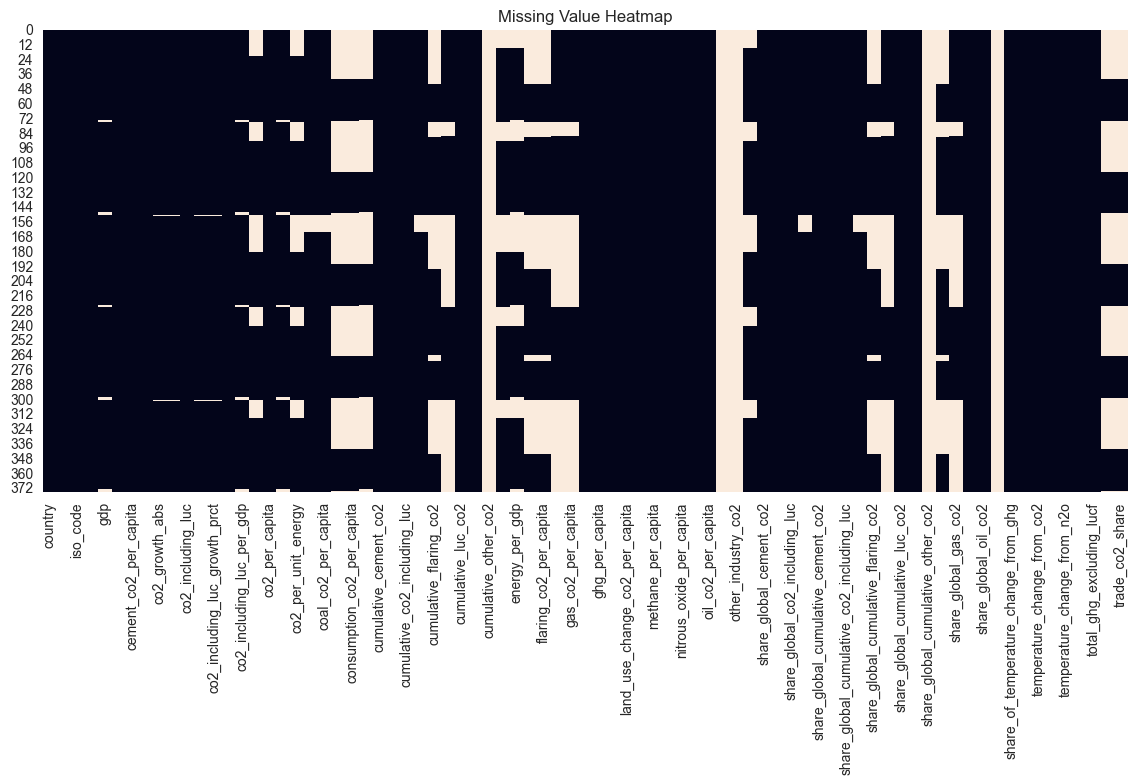

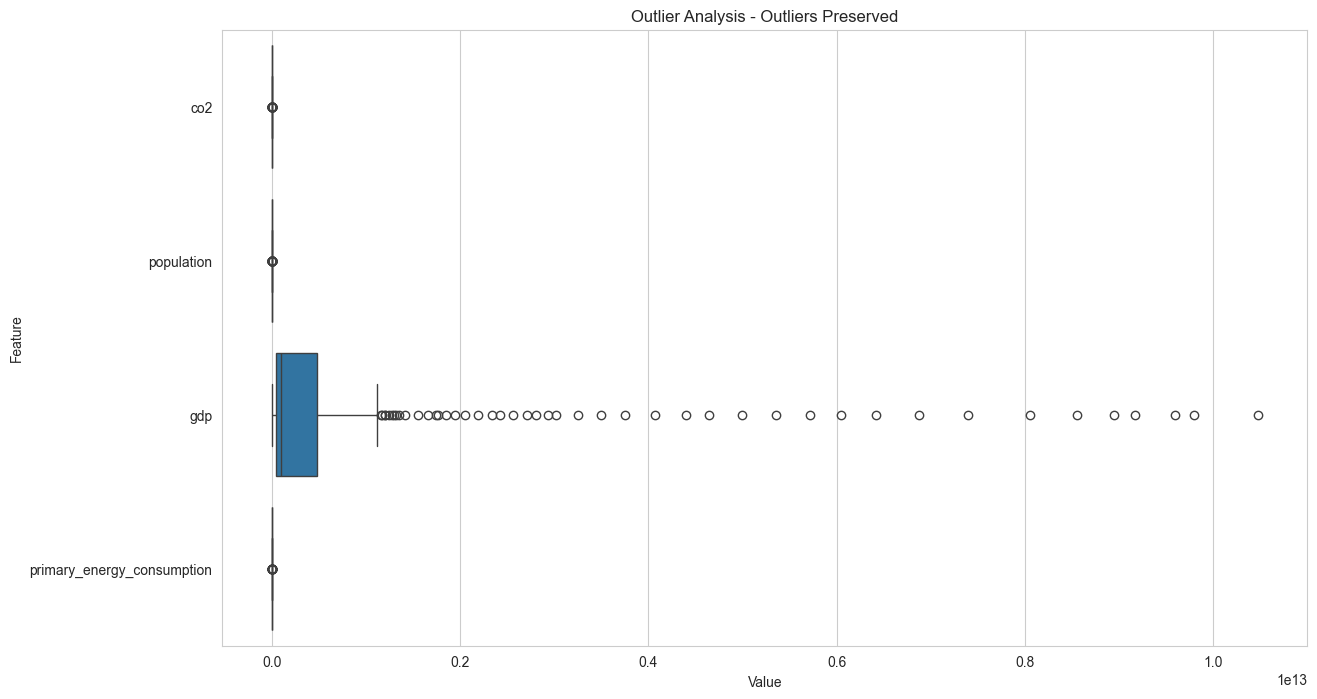

,Dataset,Countries,Rows,Columns,Duplicate_Rows,Total_Missing_Values,Year_Filter,Target
0,OWID CO2 South Asia,"India, Pakistan, Bangladesh, Sri Lanka, Nepal",375,79,0,5035,1950 onwards,co2


,Column,Missing_Count,Missing_Percentage
49,other_co2_per_capita,375,100.000000
69,share_global_other_co2,375,100.000000
64,share_global_cumulative_other_co2,375,100.000000
50,other_industry_co2,375,100.000000
32,cumulative_other_co2,375,100.000000
23,consumption_co2_per_gdp,210,56.000000
22,consumption_co2_per_capita,205,54.666667
21,consumption_co2,205,54.666667
78,trade_co2_share,205,54.666667
77,trade_co2,205,54.666667


,Feature,IQR_Outliers,ZScore_Outliers,Lower_Bound,Upper_Bound
0,co2,48,14,-1.427470e+02,2.463085e+02
1,population,67,12,-2.166553e+08,4.141019e+08
2,gdp,45,12,-6.222256e+11,1.151778e+12
3,primary_energy_consumption,34,14,-1.317594e+03,2.319676e+03


In [20]:
# ============================================================
# SECTION 7: DATA QUALITY, MISSING VALUES, OUTLIERS
# ============================================================

data_quality_report = pd.DataFrame([{
    "Dataset": "OWID CO2 South Asia",
    "Countries": ", ".join(COUNTRIES),
    "Rows": len(df),
    "Columns": df.shape[1],
    "Duplicate_Rows": df.duplicated().sum(),
    "Total_Missing_Values": df.isnull().sum().sum(),
    "Year_Filter": f"{MIN_YEAR} onwards",
    "Target": "co2"
}])

data_quality_report.to_csv("emission_data_quality_report.csv", index=False)

missing_report = pd.DataFrame({
    "Column": df.columns,
    "Missing_Count": df.isnull().sum().values,
    "Missing_Percentage": (df.isnull().sum().values / len(df)) * 100
}).sort_values(by="Missing_Percentage", ascending=False)

missing_report.to_csv("emission_missing_value_report.csv", index=False)

plt.figure(figsize=(14, 6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Value Heatmap")
save_current_plot("missing_value_heatmap.png")

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in ["year", "co2"]]

low_missing_cols = missing_report[
    (missing_report["Missing_Percentage"] > 0) &
    (missing_report["Missing_Percentage"] < 5)
]["Column"].tolist()

medium_missing_cols = missing_report[
    (missing_report["Missing_Percentage"] >= 5) &
    (missing_report["Missing_Percentage"] <= 30)
]["Column"].tolist()

high_missing_cols = missing_report[
    (missing_report["Missing_Percentage"] > 50)
]["Column"].tolist()

low_missing_cols = [col for col in low_missing_cols if col in numeric_cols]
medium_missing_cols = [col for col in medium_missing_cols if col in numeric_cols]
high_missing_cols = [col for col in high_missing_cols if col in numeric_cols]

for col in low_missing_cols:
    df[col] = df[col].fillna(df[col].median())

if medium_missing_cols:
    imputer = KNNImputer(n_neighbors=3)
    df[medium_missing_cols] = imputer.fit_transform(df[medium_missing_cols])

drop_feature_cols = high_missing_cols

df.drop_duplicates(inplace=True)

outlier_cols = find_existing_columns(
    df,
    [
        "co2", "population", "gdp", "primary_energy_consumption",
        "coal_consumption", "oil_consumption", "gas_consumption",
        "renewables_consumption", "electricity_generation"
    ]
)

outlier_summary = []

for col in outlier_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    iqr_outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()

    std_value = df[col].std()

    if std_value == 0 or pd.isna(std_value):
        z_outliers = 0
    else:
        z_scores = np.abs((df[col] - df[col].mean()) / std_value)
        z_outliers = (z_scores > 3).sum()

    outlier_summary.append({
        "Feature": col,
        "IQR_Outliers": iqr_outliers,
        "ZScore_Outliers": z_outliers,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound
    })

outlier_report = pd.DataFrame(outlier_summary)
outlier_report.to_csv("emission_outlier_report.csv", index=False)

plt.figure(figsize=(14, 8))
sns.boxplot(data=df[outlier_cols].melt(var_name="Feature", value_name="Value"), x="Value", y="Feature")
plt.title("Outlier Analysis - Outliers Preserved")
save_current_plot("outlier_boxplot.png")

display(data_quality_report)
display(missing_report.head(25))
display(outlier_report)

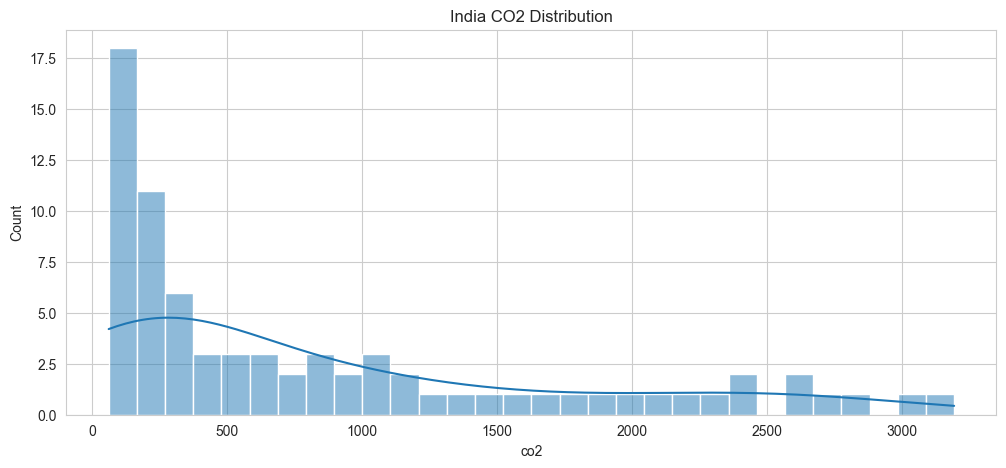

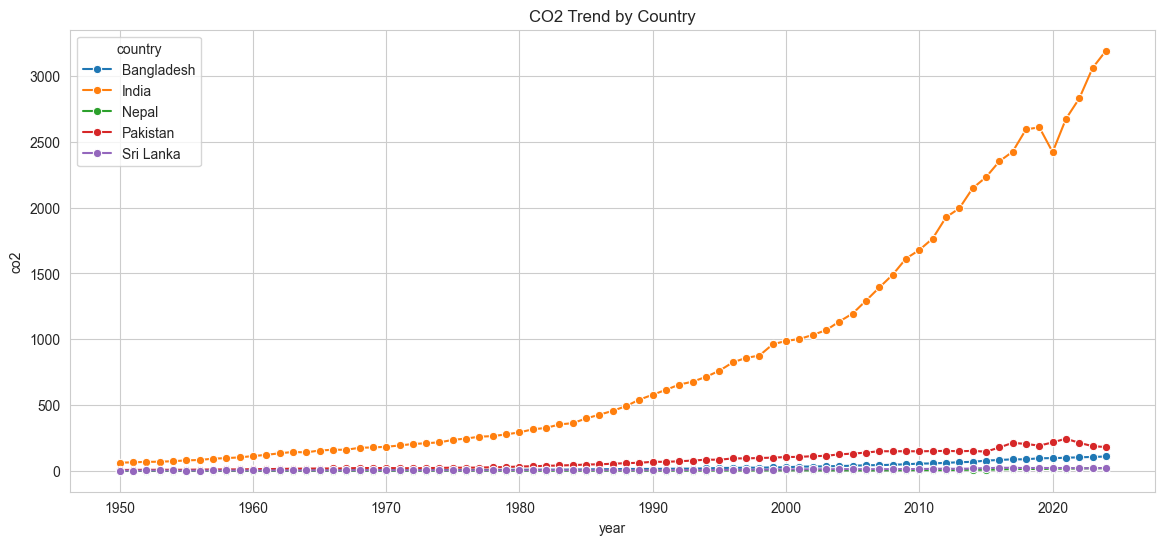

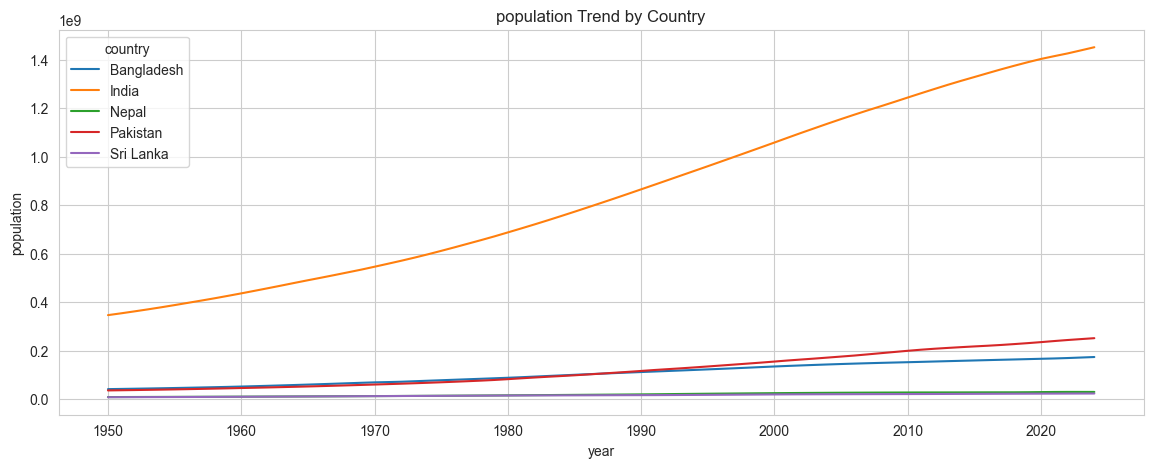

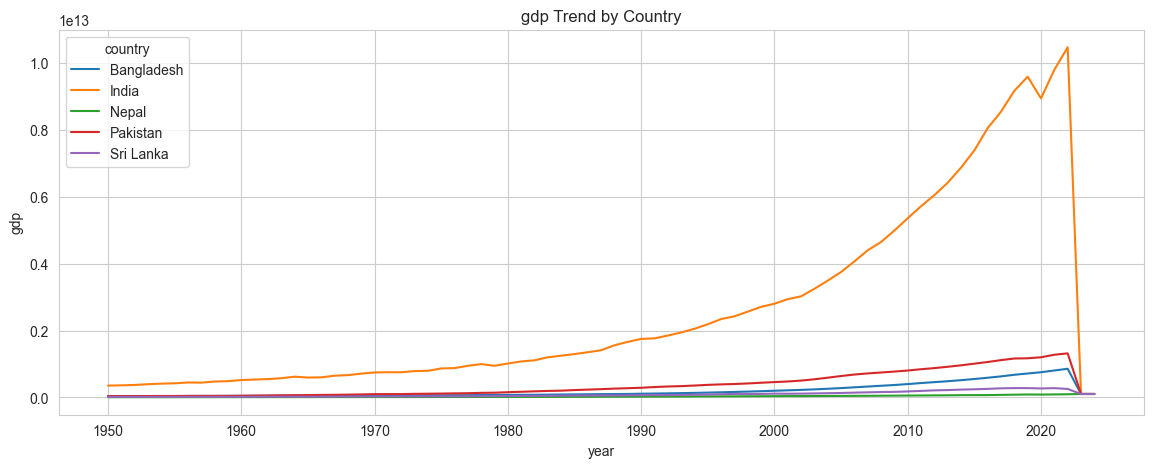

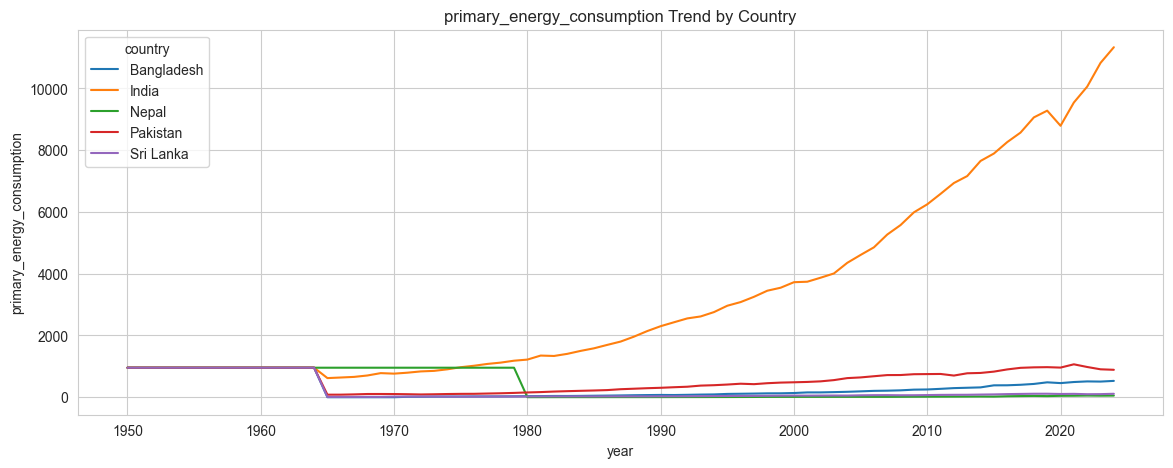

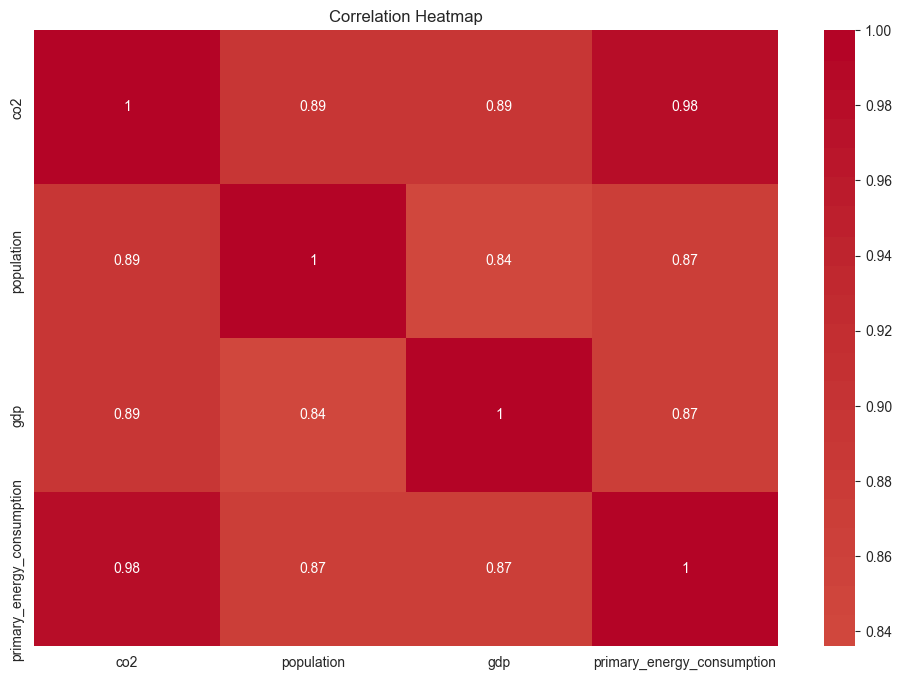

In [21]:
# ============================================================
# SECTION 8: EDA AND CORRELATION
# ============================================================

plt.figure(figsize=(12, 5))
sns.histplot(df[df["country"] == "India"]["co2"], kde=True, bins=30)
plt.title("India CO2 Distribution")
save_current_plot("india_co2_distribution.png")

plt.figure(figsize=(14, 6))
sns.lineplot(data=df, x="year", y="co2", hue="country", marker="o")
plt.title("CO2 Trend by Country")
save_current_plot("country_co2_trend.png")

trend_cols = find_existing_columns(
    df,
    [
        "population", "gdp", "primary_energy_consumption",
        "coal_consumption", "oil_consumption", "gas_consumption",
        "renewables_consumption", "electricity_generation"
    ]
)

for col in trend_cols:
    plt.figure(figsize=(14, 5))
    sns.lineplot(data=df, x="year", y=col, hue="country")
    plt.title(f"{col} Trend by Country")
    plt.show()

corr_cols = find_existing_columns(
    df,
    [
        "co2", "population", "gdp", "primary_energy_consumption",
        "coal_consumption", "oil_consumption", "gas_consumption",
        "renewables_consumption", "electricity_generation"
    ]
)

correlation_matrix = df[corr_cols].corr()
correlation_matrix.to_csv("feature_correlation.csv")

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
save_current_plot("correlation_heatmap.png")

In [22]:
# ============================================================
# SECTION 9: FEATURE ENGINEERING
# ============================================================

country_dummies = pd.get_dummies(df["country"], prefix="country", dtype=int)
df = pd.concat([df, country_dummies], axis=1)

total_energy = (
    df.get("coal_consumption", 0) +
    df.get("oil_consumption", 0) +
    df.get("gas_consumption", 0) +
    df.get("renewables_consumption", 0)
)

fossil_energy = (
    df.get("coal_consumption", 0) +
    df.get("oil_consumption", 0) +
    df.get("gas_consumption", 0)
)

df["fossil_dependency_score"] = safe_divide(fossil_energy, total_energy)
df["renewable_fossil_ratio"] = safe_divide(df.get("renewables_consumption", 0), fossil_energy)

df["population_growth_rate"] = df.groupby("country")["population"].pct_change() if "population" in df.columns else 0
df["gdp_growth_rate"] = df.groupby("country")["gdp"].pct_change() if "gdp" in df.columns else 0
df["renewable_growth_rate"] = df.groupby("country")["renewables_consumption"].pct_change() if "renewables_consumption" in df.columns else 0
df["energy_growth_rate"] = df.groupby("country")["primary_energy_consumption"].pct_change() if "primary_energy_consumption" in df.columns else 0

df["gdp_per_capita"] = safe_divide(df.get("gdp", 0), df.get("population", 0))
df["energy_intensity"] = safe_divide(df.get("primary_energy_consumption", 0), df.get("gdp", 0))
df["renewable_share_change"] = df.groupby("country")["renewables_share_energy"].pct_change() if "renewables_share_energy" in df.columns else 0

df["carbon_intensity"] = safe_divide(df["co2"], df.get("primary_energy_consumption", 0))

df["lag_1"] = df.groupby("country")["co2"].shift(1)
df["lag_3"] = df.groupby("country")["co2"].shift(3)
df["lag_5"] = df.groupby("country")["co2"].shift(5)
df["lag_10"] = df.groupby("country")["co2"].shift(10)

df["rolling_mean_3"] = df.groupby("country")["co2"].shift(1).rolling(window=3).mean()
df["rolling_mean_5"] = df.groupby("country")["co2"].shift(1).rolling(window=5).mean()
df["rolling_mean_10"] = df.groupby("country")["co2"].shift(1).rolling(window=10).mean()
df["rolling_std_3"] = df.groupby("country")["co2"].shift(1).rolling(window=3).std()

df.replace([np.inf, -np.inf], np.nan, inplace=True)

for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df.groupby("country")[col].transform(lambda s: s.fillna(s.median()))
    df[col] = df[col].fillna(df[col].median())

print("Feature engineering completed.")
display(df.head())

Feature engineering completed.


,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,renewable_share_change,carbon_intensity,lag_1,lag_3,lag_5,lag_10,rolling_mean_3,rolling_mean_5,rolling_mean_10,rolling_std_3
0,Bangladesh,1950,BGD,41206857.0,3.930118e+10,0.001815,0.000044,0.993068,0.802835,422.027222,...,0,0.001039,11.602767,10.797484,9.633161,8.188282,11.679778,11.62058,11.49078,0.749143
1,Bangladesh,1951,BGD,42022311.0,3.978116e+10,0.002231,0.000053,1.226293,0.233225,23.485302,...,0,0.001283,0.993068,10.797484,9.633161,8.188282,11.679778,11.62058,11.49078,0.749143
2,Bangladesh,1952,BGD,42893013.0,4.097478e+10,0.002341,0.000055,1.295057,0.068764,5.607474,...,0,0.001355,1.226293,10.797484,9.633161,8.188282,11.679778,11.62058,11.49078,0.749143
3,Bangladesh,1953,BGD,43791390.0,4.155335e+10,0.002566,0.000059,1.317977,0.022920,1.769805,...,0,0.001379,1.295057,0.993068,9.633161,8.188282,1.171473,11.62058,11.49078,0.158282
4,Bangladesh,1954,BGD,44741299.0,4.237309e+10,0.002842,0.000064,1.338604,0.020627,1.565051,...,0,0.001401,1.317977,1.226293,9.633161,8.188282,1.279776,11.62058,11.49078,0.047714


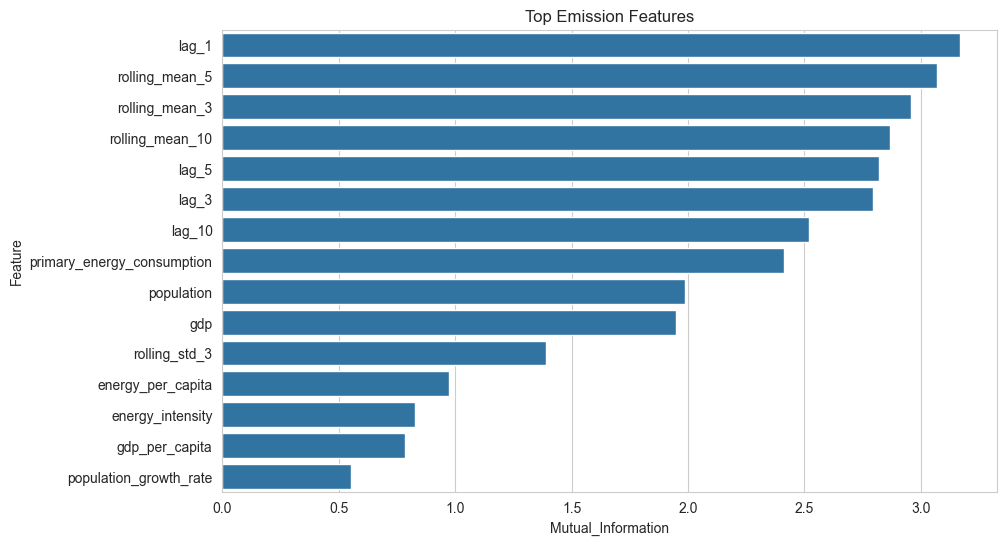

Selected Features:
['lag_1', 'rolling_mean_5', 'rolling_mean_3', 'rolling_mean_10', 'lag_5', 'lag_3', 'lag_10', 'primary_energy_consumption', 'population', 'gdp', 'rolling_std_3', 'energy_per_capita', 'gdp_per_capita', 'population_growth_rate', 'year']

Country one-hot features selected:
[]


In [23]:
# ============================================================
# SECTION 10: FEATURE SELECTION USING MI + RFE
# ============================================================

country_features = [col for col in df.columns if col.startswith("country_")]

import_export_features = [
    col for col in df.columns
    if ("import" in col.lower() or "export" in col.lower())
]

base_features = [
    "year", "population", "gdp", "primary_energy_consumption",
    "energy_per_capita", "coal_consumption", "oil_consumption",
    "gas_consumption", "renewables_consumption", "renewables_share_energy",
    "renewables_electricity", "renewables_share_elec",
    "coal_share_energy", "oil_share_energy", "gas_share_energy",
    "electricity_generation", "fossil_dependency_score",
    "renewable_fossil_ratio", "population_growth_rate",
    "gdp_growth_rate", "gdp_per_capita", "energy_intensity",
    "renewable_growth_rate", "renewable_share_change",
    "energy_growth_rate", "lag_1", "lag_3", "lag_5",
    "lag_10", "rolling_mean_3", "rolling_mean_5",
    "rolling_mean_10", "rolling_std_3"
] + country_features + import_export_features

all_leakage_columns = list(set(LEAKAGE_COLUMNS + TEMPERATURE_COLUMNS))

candidate_features = [
    col for col in base_features
    if col in df.columns
    and col not in all_leakage_columns
    and col not in drop_feature_cols
]

feature_selection_df = df.dropna(subset=["co2"]).copy()

X_all = feature_selection_df[candidate_features]
y_all = feature_selection_df["co2"]

mi_scores = mutual_info_regression(X_all, y_all, random_state=RANDOM_STATE)

mi_ranking = pd.DataFrame({
    "Feature": candidate_features,
    "Mutual_Information": mi_scores
}).sort_values(by="Mutual_Information", ascending=False)

rfe_estimator = RandomForestRegressor(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rfe = RFE(
    estimator=rfe_estimator,
    n_features_to_select=min(15, len(candidate_features))
)

rfe.fit(X_all, y_all)

rfe_selected = [
    feature for feature, selected in zip(candidate_features, rfe.support_)
    if selected
]

top_mi_features = mi_ranking.head(min(20, len(mi_ranking)))["Feature"].tolist()

selected_features = [f for f in top_mi_features if f in rfe_selected]

if len(selected_features) < 10:
    selected_features = list(dict.fromkeys(rfe_selected + top_mi_features))[:15]

rfe_ranking = pd.DataFrame({
    "Feature": candidate_features,
    "RFE_Selected": rfe.support_,
    "RFE_Ranking": rfe.ranking_
})

feature_ranking = mi_ranking.merge(rfe_ranking, on="Feature", how="left")

pd.DataFrame({"Feature": selected_features}).to_csv("selected_features.csv", index=False)
feature_ranking.to_csv("feature_ranking.csv", index=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=mi_ranking.head(15), x="Mutual_Information", y="Feature")
plt.title("Top Emission Features")
save_current_plot("selected_feature_ranking.png")

print("Selected Features:")
print(selected_features)

print("\nCountry one-hot features selected:")
print([f for f in selected_features if f.startswith("country_")])

In [24]:
# ============================================================
# SECTION 11: EXPERIMENT DATA SPLITTING
# ============================================================

india_model_df = df[df["country"] == "India"].copy()
regional_model_df = df[df["country"].isin(COUNTRIES)].copy()

india_train_df, india_val_df, india_test_df = chronological_split_df(india_model_df)
regional_train_df, regional_val_df, regional_test_df = split_by_country(regional_model_df, COUNTRIES)

regional_india_test_df = regional_test_df[regional_test_df["country"] == "India"].copy()

X_india_train = india_train_df[selected_features]
y_india_train = india_train_df["co2"]

X_india_val = india_val_df[selected_features]
y_india_val = india_val_df["co2"]

X_india_test = india_test_df[selected_features]
y_india_test = india_test_df["co2"]

X_regional_train = regional_train_df[selected_features]
y_regional_train = regional_train_df["co2"]

X_regional_val = regional_val_df[selected_features]
y_regional_val = regional_val_df["co2"]

X_regional_india_test = regional_india_test_df[selected_features]
y_regional_india_test = regional_india_test_df["co2"]

safe_splits_india = min(N_SPLITS, max(2, len(X_india_train) // 10))
safe_splits_regional = min(N_SPLITS, max(2, len(X_regional_train) // 10))

india_tscv = TimeSeriesSplit(n_splits=safe_splits_india)
regional_tscv = TimeSeriesSplit(n_splits=safe_splits_regional)

print("India Train:", X_india_train.shape)
print("India Validation:", X_india_val.shape)
print("India Test:", X_india_test.shape)

print("Regional Train:", X_regional_train.shape)
print("Regional Validation:", X_regional_val.shape)
print("Regional India Test:", X_regional_india_test.shape)

India Train: (52, 15)
India Validation: (11, 15)
India Test: (12, 15)
Regional Train: (260, 15)
Regional Validation: (55, 15)
Regional India Test: (12, 15)


In [25]:
# ============================================================
# SECTION 12: TRAINING PIPELINE
# ============================================================

def fit_randomized_then_grid(model, random_params, grid_params, X_train, y_train, cv):
    total_combinations = np.prod([len(v) for v in random_params.values()])

    random_search = RandomizedSearchCV(
        model,
        random_params,
        n_iter=min(8, total_combinations),
        cv=cv,
        scoring="r2",
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=0
    )

    random_search.fit(X_train, y_train)

    grid_search = GridSearchCV(
        model,
        grid_params(random_search.best_params_),
        cv=cv,
        scoring="r2",
        n_jobs=-1,
        verbose=0
    )

    grid_search.fit(X_train, y_train)

    return grid_search.best_estimator_, random_search.best_params_, grid_search.best_params_


def train_experiment(X_train, y_train, X_val, y_val, X_test, y_test, cv, experiment_name):
    linear_model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ])

    rf_base = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)

    rf_random_params = {
        "n_estimators": [100, 200, 300],
        "max_depth": [None, 5, 10],
        "min_samples_split": [2, 5]
    }

    def rf_grid_params(best):
        return {
            "n_estimators": [best["n_estimators"]],
            "max_depth": [best["max_depth"]],
            "min_samples_split": [best["min_samples_split"]]
        }

    tuned_rf, rf_random_best, rf_grid_best = fit_randomized_then_grid(
        rf_base, rf_random_params, rf_grid_params, X_train, y_train, cv
    )

    xgb_base = XGBRegressor(
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    xgb_random_params = {
        "n_estimators": [100, 200, 300],
        "max_depth": [2, 3, 5],
        "learning_rate": [0.03, 0.05, 0.07],
        "subsample": [0.8, 1.0]
    }

    def xgb_grid_params(best):
        return {
            "n_estimators": [best["n_estimators"]],
            "max_depth": [best["max_depth"]],
            "learning_rate": [best["learning_rate"]],
            "subsample": [best["subsample"]]
        }

    tuned_xgb, xgb_random_best, xgb_grid_best = fit_randomized_then_grid(
        xgb_base, xgb_random_params, xgb_grid_params, X_train, y_train, cv
    )

    et_base = ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=-1)

    et_random_params = {
        "n_estimators": [100, 200, 300],
        "max_depth": [None, 5, 10],
        "min_samples_split": [2, 5]
    }

    def et_grid_params(best):
        return {
            "n_estimators": [best["n_estimators"]],
            "max_depth": [best["max_depth"]],
            "min_samples_split": [best["min_samples_split"]]
        }

    tuned_et, et_random_best, et_grid_best = fit_randomized_then_grid(
        et_base, et_random_params, et_grid_params, X_train, y_train, cv
    )

    voting_model = VotingRegressor(
        estimators=[
            ("lr", linear_model),
            ("rf", tuned_rf),
            ("xgb", tuned_xgb)
        ],
        n_jobs=-1
    )

    stacking_model = TimeSeriesStackingRegressor(
        estimators=[
            ("rf", tuned_rf),
            ("xgb", tuned_xgb),
            ("et", tuned_et)
        ],
        final_estimator=LinearRegression(),
        n_splits=N_SPLITS
    )

    models = {
        "Linear Regression": linear_model,
        "Random Forest": tuned_rf,
        "XGBoost": tuned_xgb,
        "Extra Trees": tuned_et,
        "Voting Regressor": voting_model,
        "TimeSeries Stacking Regressor": stacking_model
    }

    results = []
    predictions = {}

    for model_name, model in models.items():
        print(f"{experiment_name}: Training {model_name}")

        metrics, val_pred, test_pred = evaluate_model(
            model, model_name,
            X_train, y_train,
            X_val, y_val,
            X_test, y_test,
            cv
        )

        metrics["Experiment"] = experiment_name
        results.append(metrics)
        predictions[model_name] = test_pred

    results_df = pd.DataFrame(results)

    ranking_df = results_df.sort_values(
        by=["CV_Mean_R2", "Validation_RMSE", "Test_RMSE"],
        ascending=[False, True, True]
    ).reset_index(drop=True)

    ranking_df["Rank"] = range(1, len(ranking_df) + 1)

    best_model_name = ranking_df.loc[0, "Model"]
    best_model = models[best_model_name]

    best_parameters = {
        "rf_random_best": rf_random_best,
        "rf_grid_best": rf_grid_best,
        "xgb_random_best": xgb_random_best,
        "xgb_grid_best": xgb_grid_best,
        "et_random_best": et_random_best,
        "et_grid_best": et_grid_best
    }

    return {
        "models": models,
        "results_df": results_df,
        "ranking_df": ranking_df,
        "predictions": predictions,
        "best_model_name": best_model_name,
        "best_model": best_model,
        "best_metrics": ranking_df.loc[0].to_dict(),
        "xgb_model": tuned_xgb,
        "best_parameters": best_parameters
    }

In [26]:
# ============================================================
# SECTION 13: TRAIN EXPERIMENTS
# ============================================================

india_experiment = train_experiment(
    X_india_train, y_india_train,
    X_india_val, y_india_val,
    X_india_test, y_india_test,
    india_tscv,
    "India Only"
)

regional_experiment = train_experiment(
    X_regional_train, y_regional_train,
    X_regional_val, y_regional_val,
    X_regional_india_test, y_regional_india_test,
    regional_tscv,
    "South Asia Regional"
)

model_comparison = pd.concat(
    [india_experiment["ranking_df"], regional_experiment["ranking_df"]],
    axis=0,
    ignore_index=True
)

model_comparison.to_csv("model_comparison.csv", index=False)
model_comparison.to_csv("metrics.csv", index=False)

display(model_comparison)

India Only: Training Linear Regression
India Only: Training Random Forest
India Only: Training XGBoost
India Only: Training Extra Trees
India Only: Training Voting Regressor
India Only: Training TimeSeries Stacking Regressor
South Asia Regional: Training Linear Regression
South Asia Regional: Training Random Forest
South Asia Regional: Training XGBoost
South Asia Regional: Training Extra Trees
South Asia Regional: Training Voting Regressor
South Asia Regional: Training TimeSeries Stacking Regressor


,Model,Train_R2,Validation_R2,Test_R2,Train_RMSE,Validation_RMSE,Test_RMSE,MAE,RMSE,MAPE,CV_Mean_R2,CV_Std_R2,Training_Time,Prediction_Time,Overfitting_Gap,Experiment,Rank
0,Linear Regression,0.999328,0.759846,-6.128091,7.174205e+00,140.786317,917.921494,723.452771,917.921494,26.481311,0.101623,1.041794,0.007040,0.005169,7.127419,India Only,1
1,Voting Regressor,0.999741,-0.060046,-10.136598,4.452860e+00,295.786032,1147.348065,1023.853375,1147.348065,38.711675,-0.756090,0.621009,0.330234,0.176007,11.136339,India Only,2
2,XGBoost,0.999995,-2.140714,-20.279679,6.333726e-01,509.130985,1585.993723,1548.279867,1585.993723,60.114349,-3.554543,1.088746,0.610501,0.010002,21.279674,India Only,3
3,Random Forest,0.999107,-2.229573,-22.013765,8.268016e+00,516.283143,1649.349747,1595.842974,1649.349747,61.691930,-4.567154,1.611175,0.296625,0.175592,23.012872,India Only,4
4,Extra Trees,0.999932,-2.119914,-21.886245,2.281518e+00,507.442326,1644.773858,1589.551617,1644.773858,61.415191,-5.178201,1.128215,0.582530,0.313813,22.886177,India Only,5
5,TimeSeries Stacking Regressor,0.737876,-0.053865,-12.471872,1.416690e+02,294.922534,1261.923116,1215.613397,1261.923116,46.832653,-32.487377,59.956240,9.211570,0.488545,13.209747,India Only,6
6,TimeSeries Stacking Regressor,0.773046,0.946356,-18.227697,8.715597e+01,130.676836,1507.587621,1348.750260,1507.587621,50.791032,0.957004,0.029581,9.940498,0.533703,19.000744,South Asia Regional,1
7,Voting Regressor,0.999676,0.958712,-11.981046,3.294402e+00,114.643781,1238.721754,982.595565,1238.721754,36.329396,0.893297,0.103931,0.910857,0.275581,12.980721,South Asia Regional,2
8,XGBoost,1.000000,0.838324,-20.185076,1.266444e-01,226.860694,1582.464371,1544.662440,1582.464371,59.969602,0.888046,0.043878,0.810276,0.014710,21.185076,South Asia Regional,3
9,Linear Regression,0.998297,0.950296,-21.964402,7.549997e+00,125.785738,1647.579938,1343.844596,1647.579938,49.526376,0.879414,0.223319,0.015643,0.006607,22.962699,South Asia Regional,4


In [27]:
# ============================================================
# SECTION 14: RESEARCH COMPARISON AND WINNER
# ============================================================

research_comparison = pd.DataFrame([
    {
        "Experiment": "India Only",
        "Best_Model": india_experiment["best_model_name"],
        "MAE": india_experiment["best_metrics"]["MAE"],
        "RMSE": india_experiment["best_metrics"]["RMSE"],
        "MAPE": india_experiment["best_metrics"]["MAPE"],
        "R2": india_experiment["best_metrics"]["Test_R2"],
        "CV_Mean_R2": india_experiment["best_metrics"]["CV_Mean_R2"],
        "Validation_RMSE": india_experiment["best_metrics"]["Validation_RMSE"],
        "Test_RMSE": india_experiment["best_metrics"]["Test_RMSE"],
        "Training_Time": india_experiment["best_metrics"]["Training_Time"],
        "Prediction_Time": india_experiment["best_metrics"]["Prediction_Time"]
    },
    {
        "Experiment": "South Asia Regional",
        "Best_Model": regional_experiment["best_model_name"],
        "MAE": regional_experiment["best_metrics"]["MAE"],
        "RMSE": regional_experiment["best_metrics"]["RMSE"],
        "MAPE": regional_experiment["best_metrics"]["MAPE"],
        "R2": regional_experiment["best_metrics"]["Test_R2"],
        "CV_Mean_R2": regional_experiment["best_metrics"]["CV_Mean_R2"],
        "Validation_RMSE": regional_experiment["best_metrics"]["Validation_RMSE"],
        "Test_RMSE": regional_experiment["best_metrics"]["Test_RMSE"],
        "Training_Time": regional_experiment["best_metrics"]["Training_Time"],
        "Prediction_Time": regional_experiment["best_metrics"]["Prediction_Time"]
    }
])

winner_experiment = research_comparison.sort_values(
    by=["CV_Mean_R2", "Validation_RMSE", "Test_RMSE"],
    ascending=[False, True, True]
).iloc[0]["Experiment"]

research_comparison["Winner"] = np.where(
    research_comparison["Experiment"] == winner_experiment,
    "Winner",
    ""
)

india_rmse = research_comparison.loc[
    research_comparison["Experiment"] == "India Only",
    "RMSE"
].iloc[0]

regional_rmse = research_comparison.loc[
    research_comparison["Experiment"] == "South Asia Regional",
    "RMSE"
].iloc[0]

improvement_percent = ((india_rmse - regional_rmse) / india_rmse) * 100

if winner_experiment == "South Asia Regional":
    research_conclusion = (
        f"Regional South Asia training improved India's emission prediction "
        f"by {improvement_percent:.2f}% based on RMSE. "
        f"Therefore, the proposed Multi-Agent Framework uses the South Asia model "
        f"inside the Emission Monitoring Agent."
    )
else:
    research_conclusion = (
        f"India-only training performed better by {abs(improvement_percent):.2f}% based on RMSE. "
        f"Therefore, the Emission Monitoring Agent uses the India-only model for deployment."
    )

research_comparison.to_csv("research_comparison.csv", index=False)

print("Research Conclusion:")
print(research_conclusion)

display(research_comparison)

Research Conclusion:
Regional South Asia training improved India's emission prediction by -64.24% based on RMSE. Therefore, the proposed Multi-Agent Framework uses the South Asia model inside the Emission Monitoring Agent.


,Experiment,Best_Model,MAE,RMSE,MAPE,R2,CV_Mean_R2,Validation_RMSE,Test_RMSE,Training_Time,Prediction_Time,Winner
0,India Only,Linear Regression,723.452771,917.921494,26.481311,-6.128091,0.101623,140.786317,917.921494,0.007040,0.005169,
1,South Asia Regional,TimeSeries Stacking Regressor,1348.750260,1507.587621,50.791032,-18.227697,0.957004,130.676836,1507.587621,9.940498,0.533703,Winner


In [28]:
# ============================================================
# SECTION 15: SELECT FINAL MODEL
# ============================================================

if winner_experiment == "India Only":
    best_experiment = india_experiment
    final_X_train = X_india_train
    final_y_train = y_india_train
    final_X_test = X_india_test
    final_y_test = y_india_test
    final_test_df = india_test_df
else:
    best_experiment = regional_experiment
    final_X_train = X_regional_train
    final_y_train = y_regional_train
    final_X_test = X_regional_india_test
    final_y_test = y_regional_india_test
    final_test_df = regional_india_test_df

best_model = best_experiment["best_model"]
best_model_name = best_experiment["best_model_name"]
best_metrics = best_experiment["best_metrics"]
best_parameters = best_experiment["best_parameters"]

with open("best_parameters.json", "w") as file:
    json.dump(best_parameters, file, indent=4)

print("Final Best Experiment:", winner_experiment)
print("Final Best Model:", best_model_name)

Final Best Experiment: South Asia Regional
Final Best Model: TimeSeries Stacking Regressor


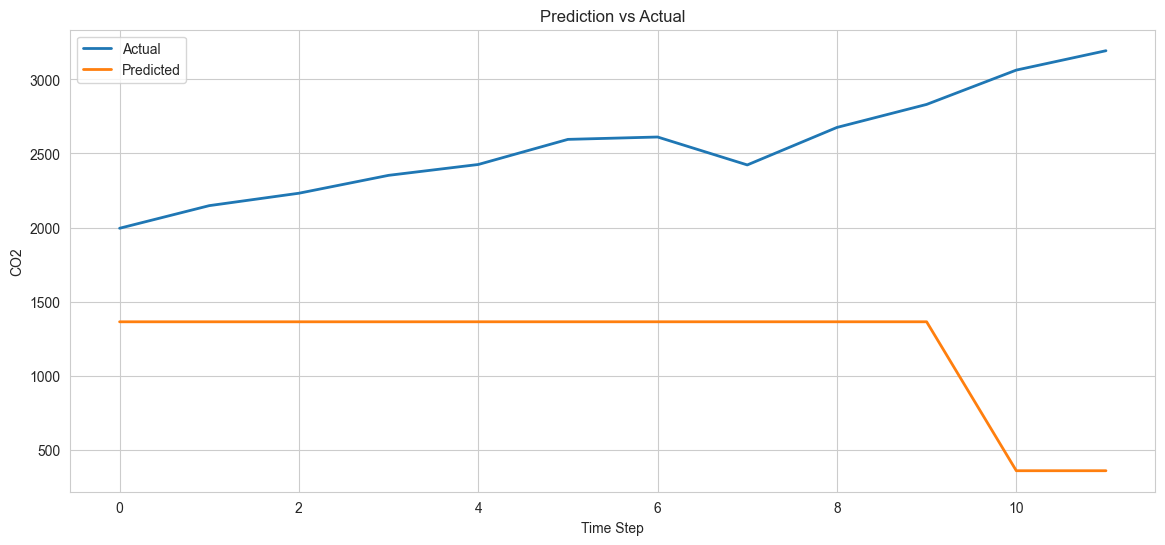

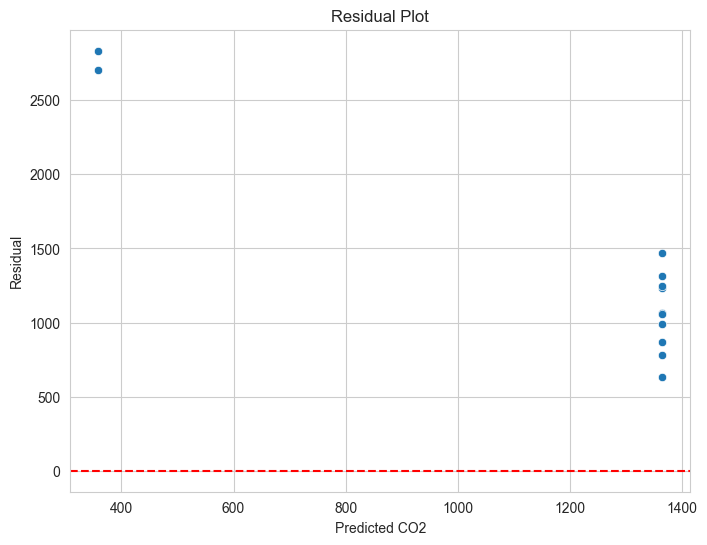

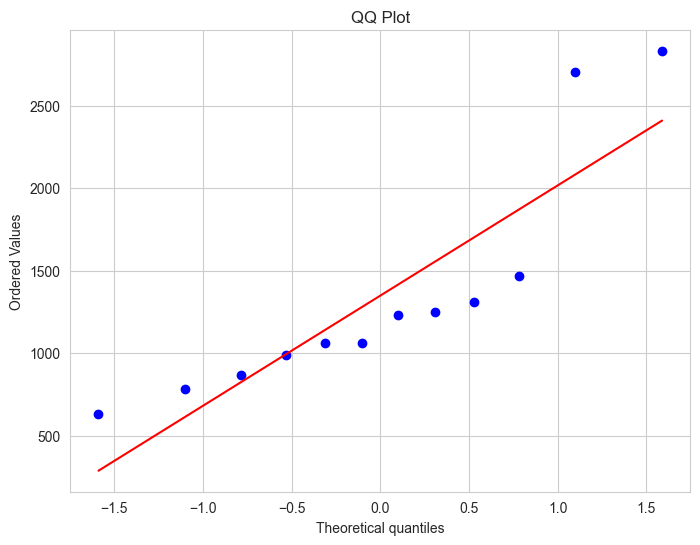

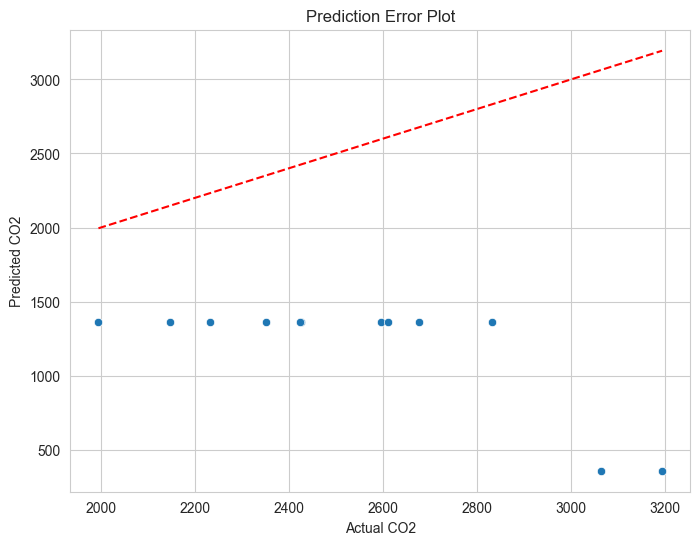

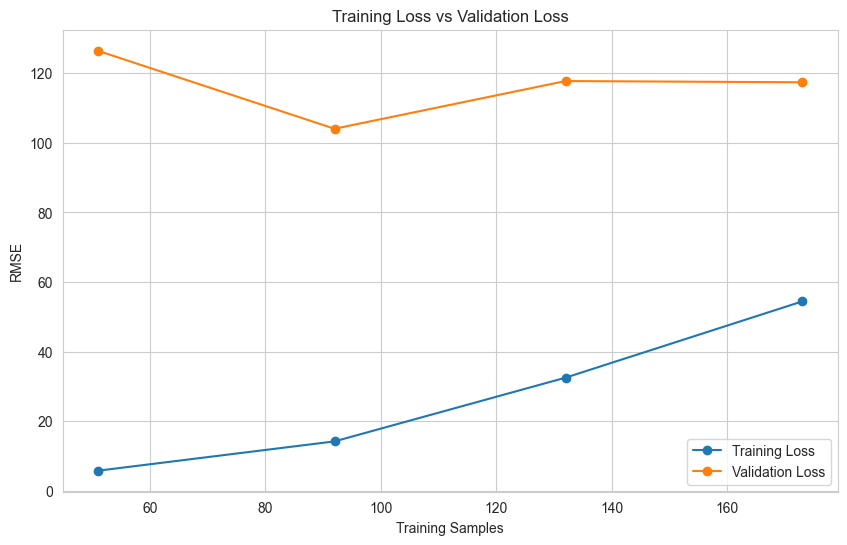

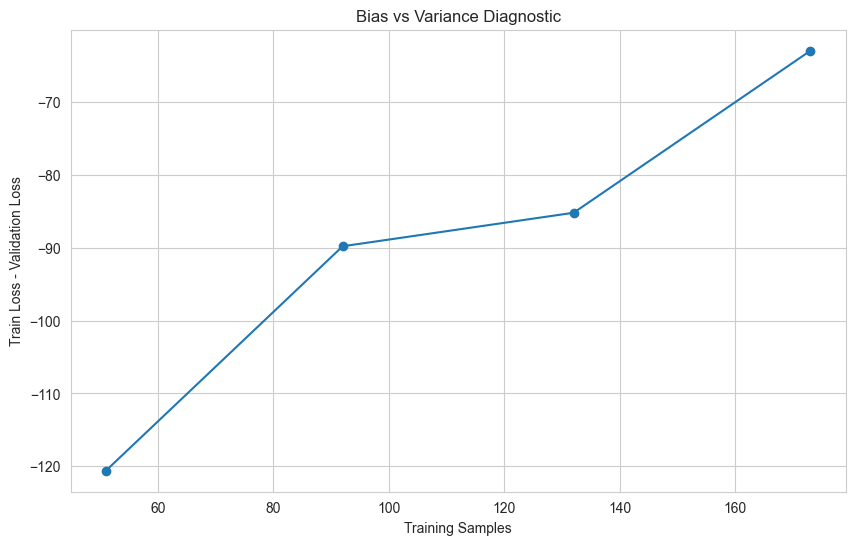

,Experiment,Model,Train_R2,Validation_R2,Test_R2,Train_RMSE,Validation_RMSE,Test_RMSE,Overfitting_Gap,Overfitting_Status
0,India Only,Linear Regression,0.999328,0.759846,-6.128091,7.174205e+00,140.786317,917.921494,7.127419,Warning: Model Overfitting
1,India Only,Voting Regressor,0.999741,-0.060046,-10.136598,4.452860e+00,295.786032,1147.348065,11.136339,Warning: Model Overfitting
2,India Only,XGBoost,0.999995,-2.140714,-20.279679,6.333726e-01,509.130985,1585.993723,21.279674,Warning: Model Overfitting
3,India Only,Random Forest,0.999107,-2.229573,-22.013765,8.268016e+00,516.283143,1649.349747,23.012872,Warning: Model Overfitting
4,India Only,Extra Trees,0.999932,-2.119914,-21.886245,2.281518e+00,507.442326,1644.773858,22.886177,Warning: Model Overfitting
5,India Only,TimeSeries Stacking Regressor,0.737876,-0.053865,-12.471872,1.416690e+02,294.922534,1261.923116,13.209747,Warning: Model Overfitting
6,South Asia Regional,TimeSeries Stacking Regressor,0.773046,0.946356,-18.227697,8.715597e+01,130.676836,1507.587621,19.000744,Warning: Model Overfitting
7,South Asia Regional,Voting Regressor,0.999676,0.958712,-11.981046,3.294402e+00,114.643781,1238.721754,12.980721,Warning: Model Overfitting
8,South Asia Regional,XGBoost,1.000000,0.838324,-20.185076,1.266444e-01,226.860694,1582.464371,21.185076,Warning: Model Overfitting
9,South Asia Regional,Linear Regression,0.998297,0.950296,-21.964402,7.549997e+00,125.785738,1647.579938,22.962699,Warning: Model Overfitting


In [29]:
# ============================================================
# SECTION 16: OVERFITTING DIAGNOSTICS
# ============================================================

overfitting_report = model_comparison[[
    "Experiment", "Model",
    "Train_R2", "Validation_R2", "Test_R2",
    "Train_RMSE", "Validation_RMSE", "Test_RMSE",
    "Overfitting_Gap"
]].copy()

overfitting_report["Overfitting_Status"] = np.where(
    overfitting_report["Overfitting_Gap"] > 0.10,
    "Warning: Model Overfitting",
    "Acceptable"
)

overfitting_report.to_csv("overfitting_report.csv", index=False)

best_pred = best_experiment["predictions"][best_model_name]
residuals = final_y_test.values - best_pred
residual_std = np.std(residuals)

plt.figure(figsize=(14, 6))
plt.plot(final_y_test.values, label="Actual", linewidth=2)
plt.plot(best_pred, label="Predicted", linewidth=2)
plt.title("Prediction vs Actual")
plt.xlabel("Time Step")
plt.ylabel("CO2")
plt.legend()
save_current_plot("prediction_vs_actual.png")

plt.figure(figsize=(8, 6))
sns.scatterplot(x=best_pred, y=residuals)
plt.axhline(0, color="red", linestyle="--")
plt.title("Residual Plot")
plt.xlabel("Predicted CO2")
plt.ylabel("Residual")
save_current_plot("residual_plot.png")

plt.figure(figsize=(8, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ Plot")
save_current_plot("qq_plot.png")

plt.figure(figsize=(8, 6))
sns.scatterplot(x=final_y_test.values, y=best_pred)
plt.plot(
    [final_y_test.min(), final_y_test.max()],
    [final_y_test.min(), final_y_test.max()],
    color="red",
    linestyle="--"
)
plt.title("Prediction Error Plot")
plt.xlabel("Actual CO2")
plt.ylabel("Predicted CO2")
save_current_plot("prediction_error_plot.png")

if ENABLE_LEARNING_CURVE:
    train_sizes, train_scores, val_scores = learning_curve(
        best_model,
        final_X_train,
        final_y_train,
        cv=min(3, max(2, len(final_X_train) // 5)),
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
        train_sizes=np.linspace(0.3, 1.0, 4)
    )

    train_loss = -train_scores.mean(axis=1)
    val_loss = -val_scores.mean(axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_loss, marker="o", label="Training Loss")
    plt.plot(train_sizes, val_loss, marker="o", label="Validation Loss")
    plt.title("Training Loss vs Validation Loss")
    plt.xlabel("Training Samples")
    plt.ylabel("RMSE")
    plt.legend()
    save_current_plot("learning_curve.png")

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_loss - val_loss, marker="o")
    plt.title("Bias vs Variance Diagnostic")
    plt.xlabel("Training Samples")
    plt.ylabel("Train Loss - Validation Loss")
    save_current_plot("bias_variance_plot.png")

display(overfitting_report)

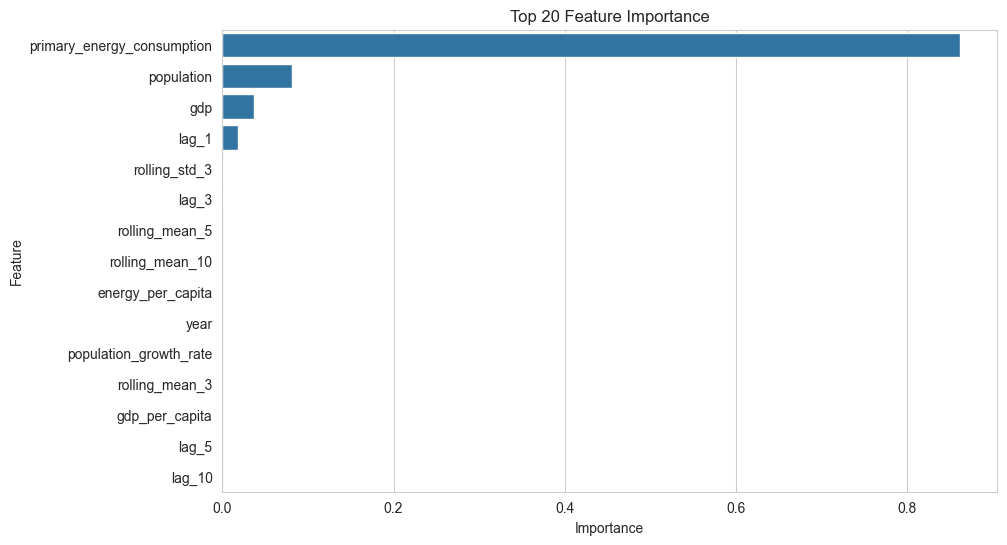

SHAP could not run: could not convert string to float: '[7.9380615E1]'


,Feature,Importance,Permutation_Importance
0,primary_energy_consumption,0.862033,0.000000
1,population,0.081424,0.000000
2,gdp,0.036998,-1.365988
3,lag_1,0.017980,0.000000
4,rolling_std_3,0.000990,0.000000
5,lag_3,0.000270,0.000000
6,rolling_mean_5,0.000071,0.000000
7,rolling_mean_10,0.000067,0.000000
8,energy_per_capita,0.000055,0.000000
9,year,0.000035,0.000000


,Feature,Mean_ABS_SHAP
0,lag_1,NaN
1,rolling_mean_5,NaN
2,rolling_mean_3,NaN
3,rolling_mean_10,NaN
4,lag_5,NaN
5,lag_3,NaN
6,lag_10,NaN
7,primary_energy_consumption,NaN
8,population,NaN
9,gdp,NaN


In [30]:
# ============================================================
# SECTION 17: EXPLAINABILITY
# ============================================================

xgb_model_for_importance = best_experiment["xgb_model"]

xgb_importance = pd.DataFrame({
    "Feature": selected_features,
    "Importance": xgb_model_for_importance.feature_importances_
}).sort_values(by="Importance", ascending=False)

perm_result = permutation_importance(
    best_model,
    final_X_test,
    final_y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

perm_importance = pd.DataFrame({
    "Feature": selected_features,
    "Permutation_Importance": perm_result.importances_mean
}).sort_values(by="Permutation_Importance", ascending=False)

feature_importance = xgb_importance.merge(
    perm_importance,
    on="Feature",
    how="left"
)

feature_importance.to_csv("feature_importance.csv", index=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=xgb_importance.head(20), x="Importance", y="Feature")
plt.title("Top 20 Feature Importance")
save_current_plot("feature_importance.png")

if ENABLE_SHAP:
    try:
        import shap

        shap_sample = final_X_test.sample(
            n=min(100, len(final_X_test)),
            random_state=RANDOM_STATE
        )

        explainer = shap.TreeExplainer(xgb_model_for_importance)
        shap_values = explainer.shap_values(shap_sample)

        shap.summary_plot(shap_values, shap_sample, show=False, max_display=20)
        plt.savefig("shap_summary.png", dpi=300, bbox_inches="tight")
        plt.show()

        shap_importance = pd.DataFrame({
            "Feature": shap_sample.columns,
            "Mean_ABS_SHAP": np.abs(shap_values).mean(axis=0)
        }).sort_values(by="Mean_ABS_SHAP", ascending=False)

        shap_importance.to_csv("top_20_shap_features.csv", index=False)

        top_shap_feature = shap_importance.iloc[0]["Feature"]

        shap.dependence_plot(
            top_shap_feature,
            shap_values,
            shap_sample,
            show=False
        )
        plt.savefig("shap_dependence_plot.png", dpi=300, bbox_inches="tight")
        plt.show()

        shap.force_plot(
            explainer.expected_value,
            shap_values[0],
            shap_sample.iloc[0],
            matplotlib=True,
            show=False
        )
        plt.savefig("shap_force_plot.png", dpi=300, bbox_inches="tight")
        plt.show()

    except Exception as e:
        print("SHAP could not run:", e)
        shap_importance = pd.DataFrame({
            "Feature": selected_features,
            "Mean_ABS_SHAP": np.nan
        })
else:
    shap_importance = pd.DataFrame({
        "Feature": selected_features,
        "Mean_ABS_SHAP": np.nan
    })

shap_importance.to_csv("emission_shap_importance.csv", index=False)

display(feature_importance.head(20))
display(shap_importance.head(20))

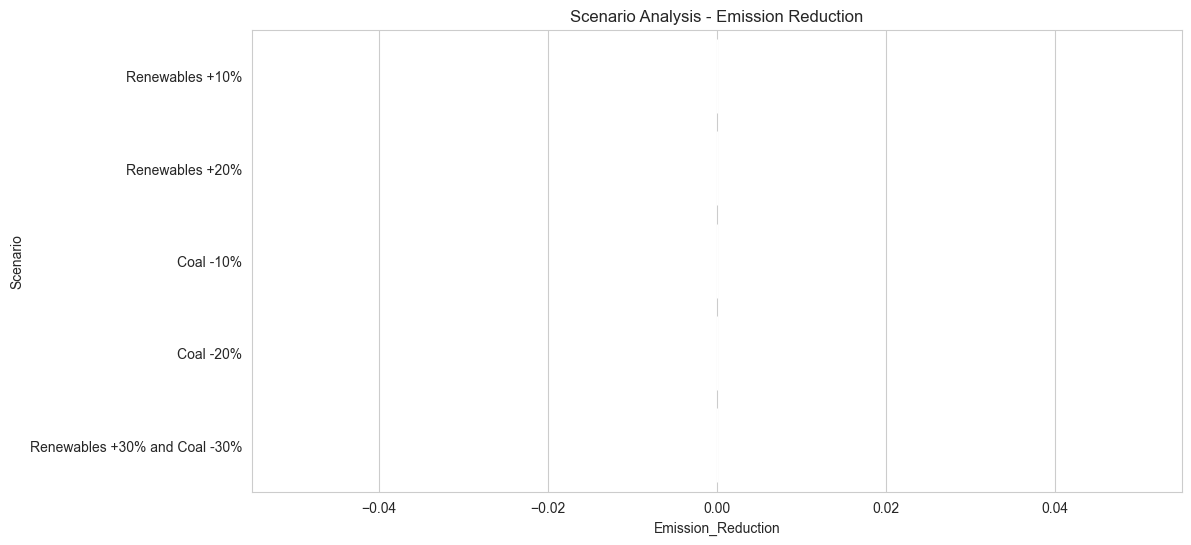

,Scenario,Baseline_CO2,Scenario_Predicted_CO2,Emission_Reduction,Carbon_Savings
0,Renewables +10%,359.164456,359.164456,0.0,0.0
1,Renewables +20%,359.164456,359.164456,0.0,0.0
2,Coal -10%,359.164456,359.164456,0.0,0.0
3,Coal -20%,359.164456,359.164456,0.0,0.0
4,Renewables +30% and Coal -30%,359.164456,359.164456,0.0,0.0


In [31]:
# ============================================================
# SECTION 18: SCENARIO ANALYSIS
# ============================================================

latest_india_row = india_model_df.sort_values("year").iloc[-1].copy()

baseline_prediction = best_model.predict(
    pd.DataFrame([latest_india_row[selected_features]])
)[0]


def simulate_scenario(base_row, changes):
    scenario_row = base_row.copy()

    for feature, pct_change in changes.items():
        if feature in scenario_row.index:
            scenario_row[feature] = scenario_row[feature] * (1 + pct_change)

    scenario_row = recalculate_engineered_features(scenario_row)

    input_df = pd.DataFrame([scenario_row[selected_features]])
    predicted_co2 = best_model.predict(input_df)[0]

    return float(predicted_co2)


scenarios = {
    "Renewables +10%": {
        "renewables_consumption": 0.10
    },
    "Renewables +20%": {
        "renewables_consumption": 0.20
    },
    "Coal -10%": {
        "coal_consumption": -0.10
    },
    "Coal -20%": {
        "coal_consumption": -0.20
    },
    "Renewables +30% and Coal -30%": {
        "renewables_consumption": 0.30,
        "coal_consumption": -0.30
    }
}

scenario_results = []

for scenario_name, changes in scenarios.items():
    scenario_prediction = simulate_scenario(latest_india_row, changes)
    reduction = baseline_prediction - scenario_prediction

    scenario_results.append({
        "Scenario": scenario_name,
        "Baseline_CO2": baseline_prediction,
        "Scenario_Predicted_CO2": scenario_prediction,
        "Emission_Reduction": reduction,
        "Carbon_Savings": reduction
    })

scenario_results_df = pd.DataFrame(scenario_results)
scenario_results_df.to_csv("scenario_results.csv", index=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=scenario_results_df, x="Emission_Reduction", y="Scenario")
plt.title("Scenario Analysis - Emission Reduction")
save_current_plot("scenario_analysis.png")

display(scenario_results_df)

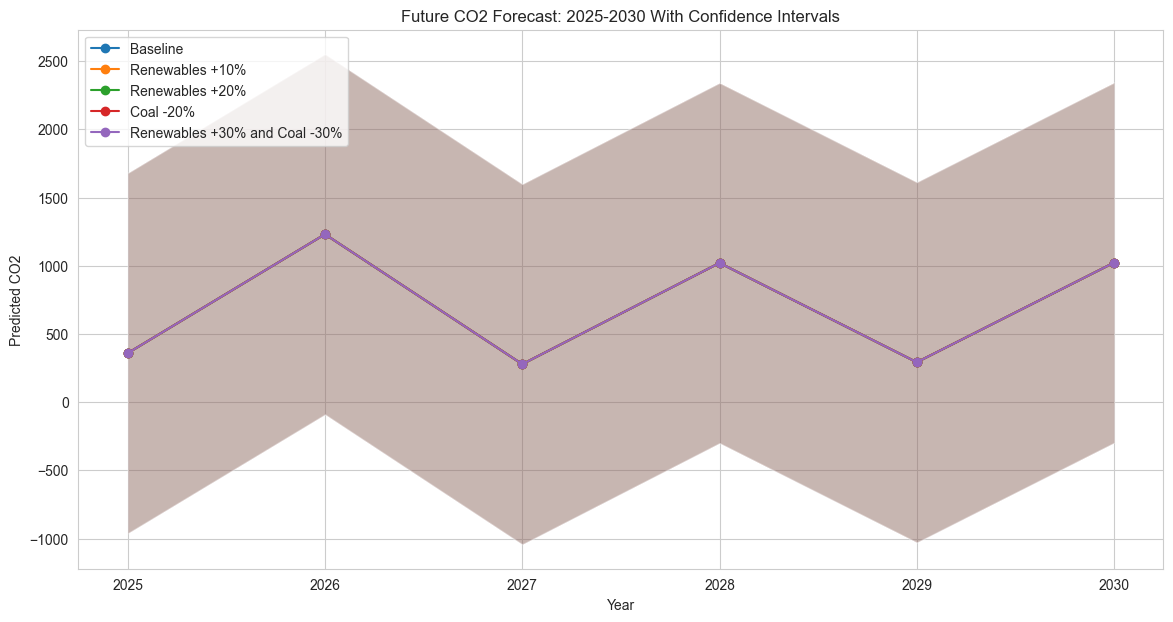

,year,predicted_co2,lower_bound,upper_bound,Scenario
0,2025,359.164456,-961.027833,1679.356746,Baseline
1,2026,1230.862857,-89.329433,2551.055147,Baseline
2,2027,278.374895,-1041.817394,1598.567185,Baseline
3,2028,1020.690326,-299.501964,2340.882615,Baseline
4,2029,292.435093,-1027.757197,1612.627383,Baseline
5,2030,1022.994613,-297.197677,2343.186902,Baseline
6,2025,359.164456,-961.027833,1679.356746,Renewables +10%
7,2026,1230.862857,-89.329433,2551.055147,Renewables +10%
8,2027,278.374895,-1041.817394,1598.567185,Renewables +10%
9,2028,1020.690326,-299.501964,2340.882615,Renewables +10%


In [32]:
# ============================================================
# SECTION 19: FORECAST 2025-2030 WITH CONFIDENCE INTERVALS
# ============================================================

forecast_outputs = []

for scenario_name, changes in {
    "Baseline": {},
    "Renewables +10%": scenarios["Renewables +10%"],
    "Renewables +20%": scenarios["Renewables +20%"],
    "Coal -20%": scenarios["Coal -20%"],
    "Renewables +30% and Coal -30%": scenarios["Renewables +30% and Coal -30%"]
}.items():
    scenario_forecast = create_future_forecast(
        best_model,
        latest_india_row,
        selected_features,
        residual_std=residual_std,
        start_year=2025,
        end_year=2030,
        scenario_changes=changes
    )

    scenario_forecast["Scenario"] = scenario_name
    forecast_outputs.append(scenario_forecast)

forecast_df = pd.concat(forecast_outputs, axis=0, ignore_index=True)
forecast_df.to_csv("emission_forecast_output.csv", index=False)

plt.figure(figsize=(14, 7))

for scenario_name in forecast_df["Scenario"].unique():
    scenario_data = forecast_df[forecast_df["Scenario"] == scenario_name]
    plt.plot(scenario_data["year"], scenario_data["predicted_co2"], marker="o", label=scenario_name)
    plt.fill_between(
        scenario_data["year"],
        scenario_data["lower_bound"],
        scenario_data["upper_bound"],
        alpha=0.12
    )

plt.title("Future CO2 Forecast: 2025-2030 With Confidence Intervals")
plt.xlabel("Year")
plt.ylabel("Predicted CO2")
plt.legend()
save_current_plot("future_forecast_2025_2030.png")

display(forecast_df)

In [33]:
# ============================================================
# SECTION 20: AGENT FUNCTIONS AND COORDINATOR OUTPUT
# ============================================================

def predict_emission(input_data=None, scenario_name="Baseline"):
    if input_data is None:
        input_data = latest_india_row[selected_features].to_dict()

    input_df = pd.DataFrame([input_data])
    input_df = input_df[selected_features]

    predicted_co2 = float(best_model.predict(input_df)[0])
    confidence = float(max(0, min(1, best_metrics["CV_Mean_R2"])))

    scenario_row = scenario_results_df[
        scenario_results_df["Scenario"] == scenario_name
    ]

    estimated_reduction = float(scenario_row["Emission_Reduction"].iloc[0]) if len(scenario_row) else 0.0

    return {
        "agent": "Emission Monitoring",
        "country": "India",
        "predicted_co2": predicted_co2,
        "confidence": confidence,
        "best_model": best_model_name,
        "scenario": scenario_name,
        "estimated_reduction": estimated_reduction,
        "timestamp": str(pd.Timestamp.now())
    }


def emission_monitoring_agent(input_data=None, scenario_name="Renewables +20%"):
    prediction_output = predict_emission(input_data, scenario_name)

    emission_level = get_emission_level(
        prediction_output["predicted_co2"],
        india_model_df["co2"]
    )

    prediction_output["emission_level"] = emission_level
    prediction_output["recommended_action"] = get_recommended_action(emission_level)
    prediction_output["status"] = "success"

    return prediction_output


emission_agent_output = emission_monitoring_agent()

with open("emission_agent_output.json", "w") as file:
    json.dump(emission_agent_output, file, indent=4)

coordinator_emission_output = {
    "predicted_co2": emission_agent_output["predicted_co2"],
    "renewable_share": float(latest_india_row.get("renewable_fossil_ratio", 0)),
    "confidence": emission_agent_output["confidence"],
    "recommended_action": emission_agent_output["recommended_action"],
    "timestamp": emission_agent_output["timestamp"],
    "status": "success"
}

with open("coordinator_emission_output.json", "w") as file:
    json.dump(coordinator_emission_output, file, indent=4)

display(emission_agent_output)
display(coordinator_emission_output)

{'agent': 'Emission Monitoring',
 'country': 'India',
 'predicted_co2': 359.1644563351853,
 'confidence': 0.9570040187058344,
 'best_model': 'TimeSeries Stacking Regressor',
 'scenario': 'Renewables +20%',
 'estimated_reduction': 0.0,
 'timestamp': '2026-06-25 17:08:29.802282',
 'emission_level': 'medium',
 'recommended_action': 'Increase Renewable Usage',
 'status': 'success'}

{'predicted_co2': 359.1644563351853,
 'renewable_share': 0.0,
 'confidence': 0.9570040187058344,
 'recommended_action': 'Increase Renewable Usage',
 'timestamp': '2026-06-25 17:08:29.802282',
 'status': 'success'}

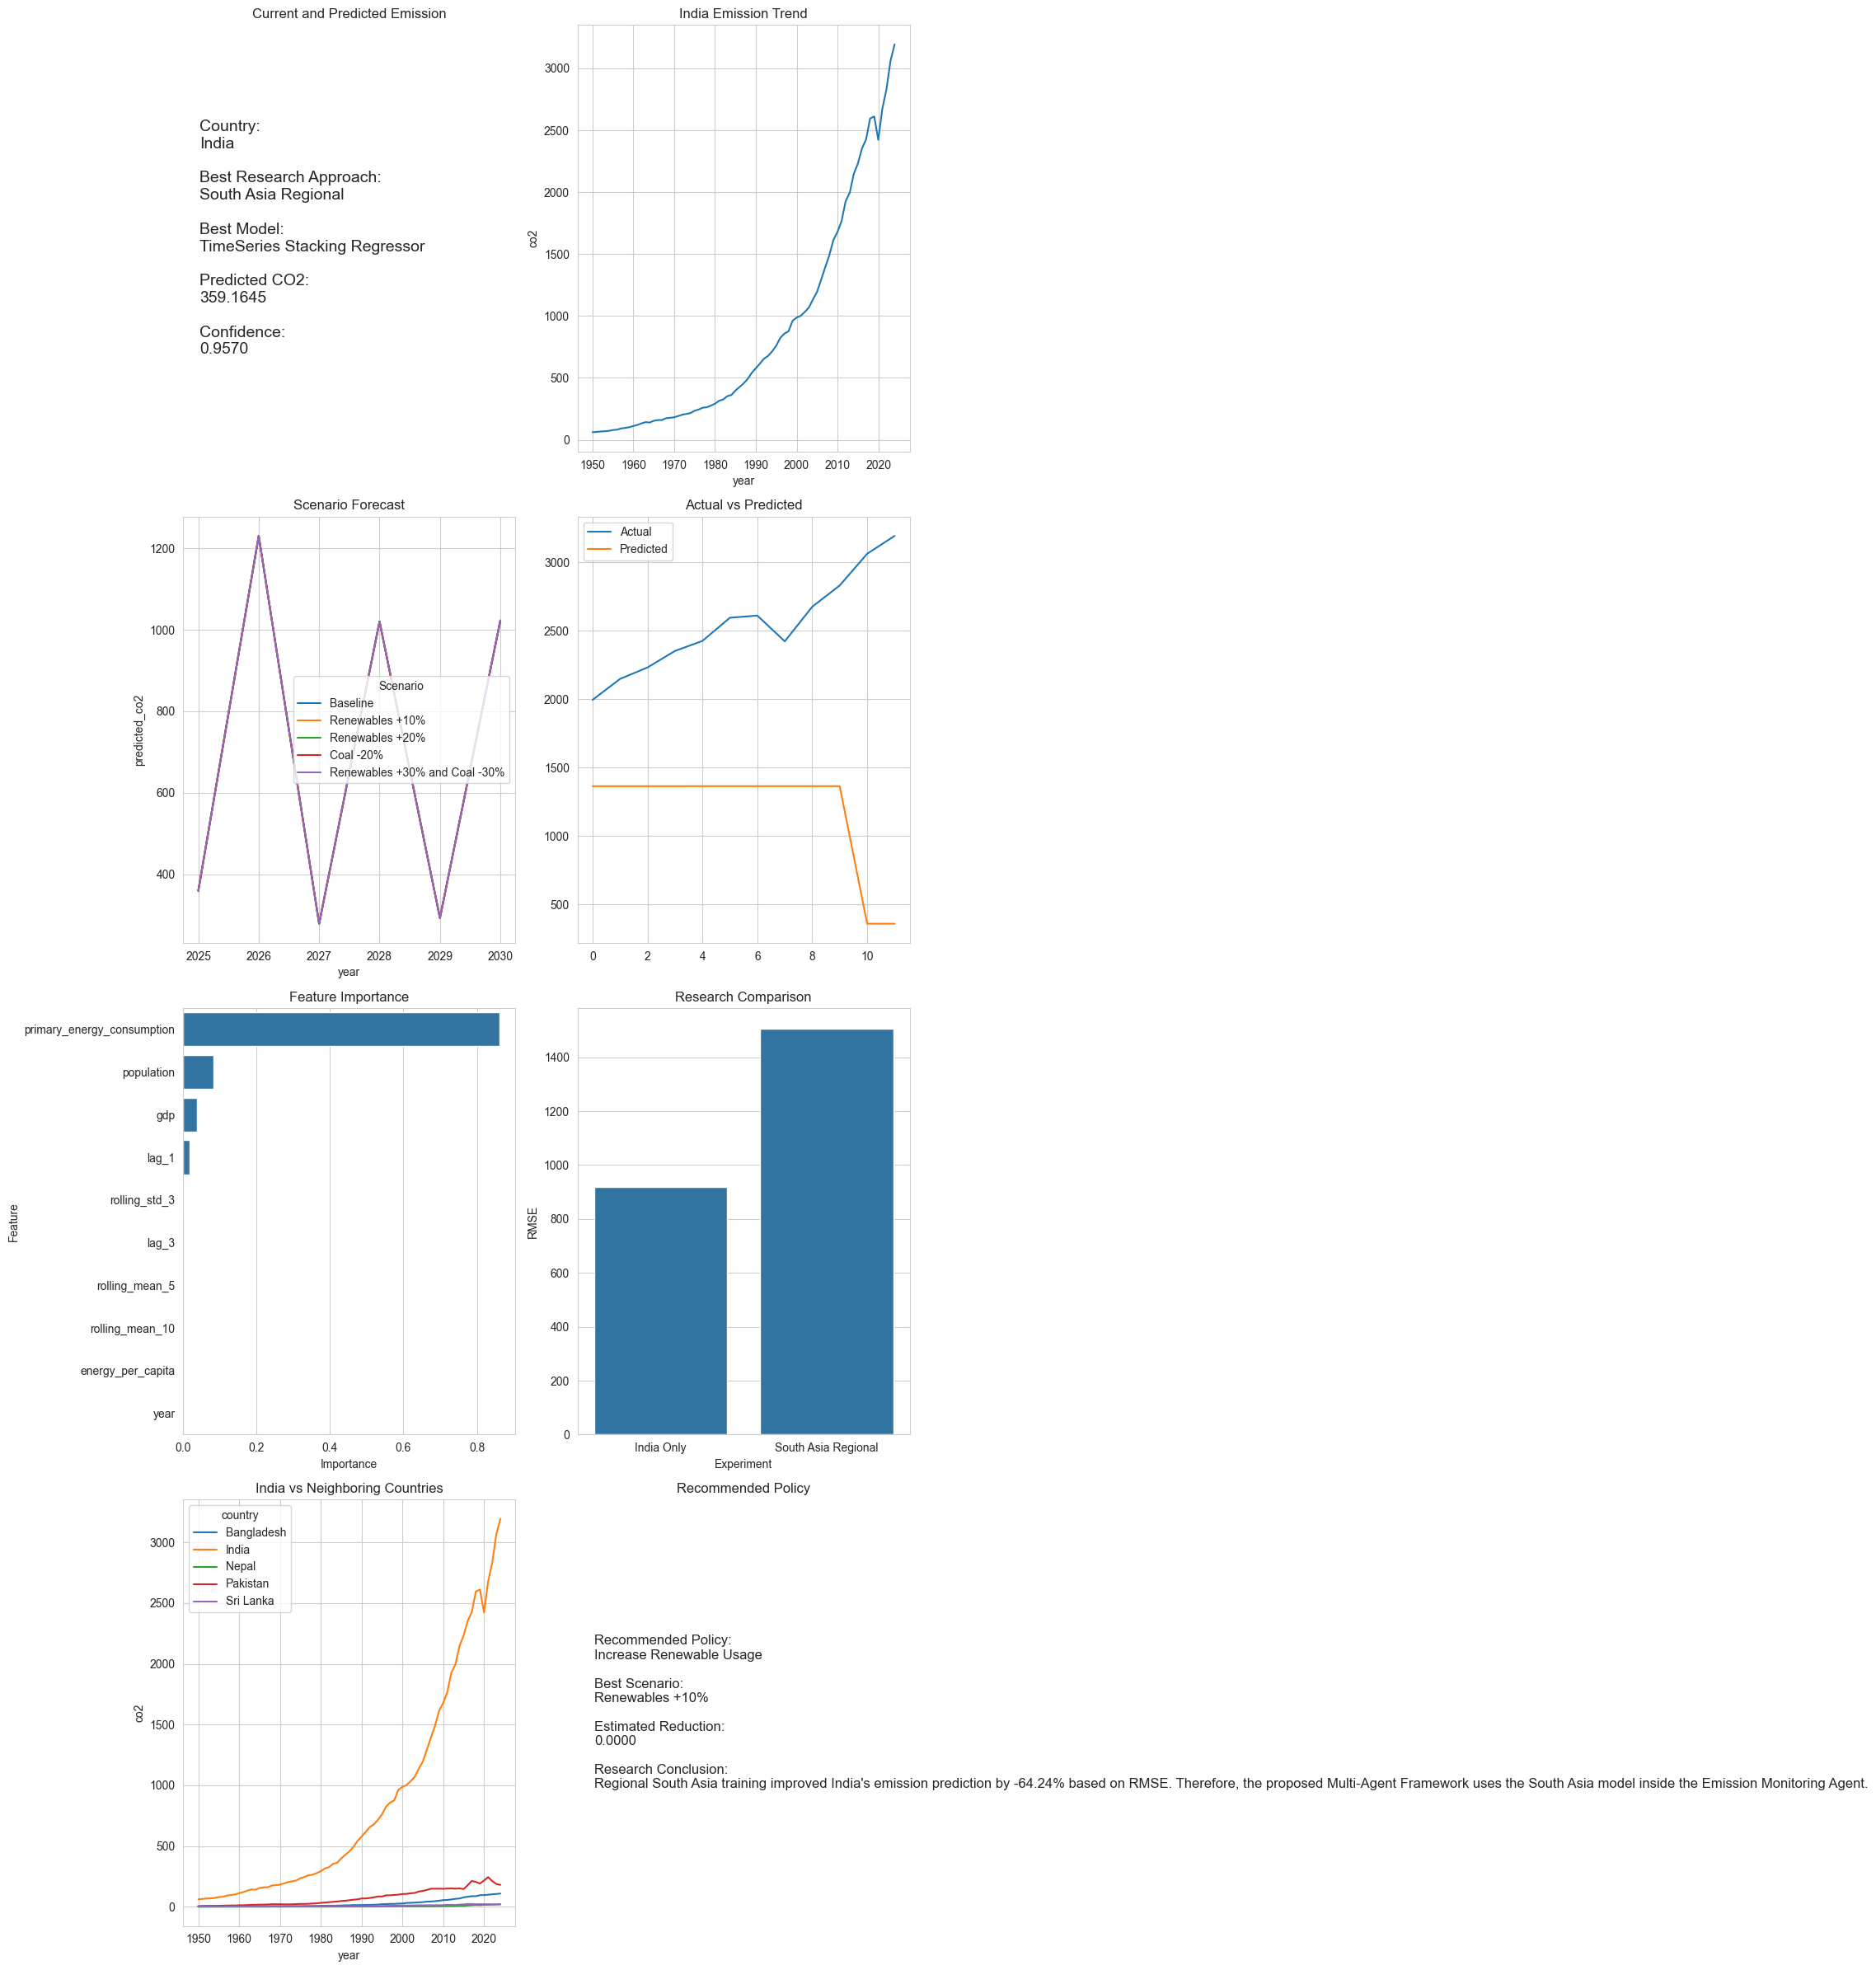

In [34]:
# ============================================================
# SECTION 21: EXECUTIVE DASHBOARD
# ============================================================

fig, axes = plt.subplots(4, 2, figsize=(20, 24))

dashboard_text = f"""
Country:
India

Best Research Approach:
{winner_experiment}

Best Model:
{best_model_name}

Predicted CO2:
{emission_agent_output["predicted_co2"]:.4f}

Confidence:
{emission_agent_output["confidence"]:.4f}
"""

axes[0, 0].axis("off")
axes[0, 0].text(0.05, 0.5, dashboard_text, fontsize=14, va="center")
axes[0, 0].set_title("Current and Predicted Emission")

sns.lineplot(data=india_model_df, x="year", y="co2", ax=axes[0, 1])
axes[0, 1].set_title("India Emission Trend")

sns.lineplot(data=forecast_df, x="year", y="predicted_co2", hue="Scenario", ax=axes[1, 0])
axes[1, 0].set_title("Scenario Forecast")

axes[1, 1].plot(final_y_test.values, label="Actual")
axes[1, 1].plot(best_pred, label="Predicted")
axes[1, 1].set_title("Actual vs Predicted")
axes[1, 1].legend()

sns.barplot(data=feature_importance.head(10), x="Importance", y="Feature", ax=axes[2, 0])
axes[2, 0].set_title("Feature Importance")

sns.barplot(data=research_comparison, x="Experiment", y="RMSE", ax=axes[2, 1])
axes[2, 1].set_title("Research Comparison")

sns.lineplot(data=df, x="year", y="co2", hue="country", ax=axes[3, 0])
axes[3, 0].set_title("India vs Neighboring Countries")

policy_text = f"""
Recommended Policy:
{emission_agent_output["recommended_action"]}

Best Scenario:
{scenario_results_df.sort_values("Emission_Reduction", ascending=False).iloc[0]["Scenario"]}

Estimated Reduction:
{scenario_results_df["Emission_Reduction"].max():.4f}

Research Conclusion:
{research_conclusion}
"""

axes[3, 1].axis("off")
axes[3, 1].text(0.05, 0.5, policy_text, fontsize=12, va="center")
axes[3, 1].set_title("Recommended Policy")

plt.tight_layout()
plt.savefig("dashboard.png", dpi=300, bbox_inches="tight")
plt.show()

In [35]:
# ============================================================
# SECTION 22: SAVE ARTIFACTS
# ============================================================

joblib.dump(best_model, "best_emission_model.pkl")

best_model_details = pd.DataFrame([{
    "Best_Experiment": winner_experiment,
    "Best_Model": best_model_name,
    "Test_R2": best_metrics["Test_R2"],
    "RMSE": best_metrics["RMSE"],
    "MAE": best_metrics["MAE"],
    "MAPE": best_metrics["MAPE"],
    "CV_Mean_R2": best_metrics["CV_Mean_R2"],
    "CV_Std_R2": best_metrics["CV_Std_R2"]
}])

best_model_details.to_csv("best_model_details.csv", index=False)

metadata = {
    "project": "Multi-Agent AI Framework for Fossil Fuel Displacement",
    "agent": "Emission Monitoring Agent",
    "dataset": DATASET_PATH,
    "countries": COUNTRIES,
    "target": "co2",
    "year_filter": f"{MIN_YEAR} onwards",
    "best_experiment": winner_experiment,
    "best_model": best_model_name,
    "selected_features": selected_features,
    "leakage_columns_removed": LEAKAGE_COLUMNS,
    "temperature_columns_excluded": TEMPERATURE_COLUMNS,
    "research_conclusion": research_conclusion,
    "sklearn_version": sklearn.__version__,
    "xgboost_version": xgboost.__version__,
    "timestamp": str(pd.Timestamp.now()),
    "status": "success"
}

with open("metadata.json", "w") as file:
    json.dump(metadata, file, indent=4)

with open("emission_features.json", "w") as file:
    json.dump(selected_features, file, indent=4)

print("Artifacts saved successfully.")

Artifacts saved successfully.


In [36]:
# ============================================================
# SECTION 23: RESEARCH REPORT AND PDF SUMMARY
# ============================================================

with pd.ExcelWriter("emission_research_report.xlsx") as writer:
    data_quality_report.to_excel(writer, sheet_name="Data Quality", index=False)
    missing_report.to_excel(writer, sheet_name="Missing Values", index=False)
    outlier_report.to_excel(writer, sheet_name="Outlier Report", index=False)
    feature_ranking.to_excel(writer, sheet_name="Feature Ranking", index=False)
    model_comparison.to_excel(writer, sheet_name="Model Comparison", index=False)
    research_comparison.to_excel(writer, sheet_name="Research Comparison", index=False)
    overfitting_report.to_excel(writer, sheet_name="Overfitting Report", index=False)
    feature_importance.to_excel(writer, sheet_name="Feature Importance", index=False)
    shap_importance.to_excel(writer, sheet_name="SHAP Importance", index=False)
    scenario_results_df.to_excel(writer, sheet_name="Scenario Analysis", index=False)
    forecast_df.to_excel(writer, sheet_name="Forecast", index=False)
    pd.DataFrame([emission_agent_output]).to_excel(writer, sheet_name="Agent Output", index=False)
    pd.DataFrame([coordinator_emission_output]).to_excel(writer, sheet_name="Coordinator Output", index=False)
    best_model_details.to_excel(writer, sheet_name="Best Model Details", index=False)

with PdfPages("research_summary.pdf") as pdf:
    fig = plt.figure(figsize=(11, 8.5))
    plt.axis("off")

    summary_text = f"""
Emission Monitoring Agent - Research Summary

Research Question:
Does South Asia regional training improve India's CO2 forecasting?

Winner:
{winner_experiment}

Best Model:
{best_model_name}

India RMSE:
{india_rmse:.4f}

Regional RMSE:
{regional_rmse:.4f}

Improvement:
{improvement_percent:.2f}%

Conclusion:
{research_conclusion}

Recommended Policy:
{emission_agent_output["recommended_action"]}
"""
    plt.text(0.05, 0.95, summary_text, fontsize=12, va="top")
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

print("Research report and PDF summary exported successfully.")

Research report and PDF summary exported successfully.


In [37]:
# ============================================================
# SECTION 24: FINAL RESEARCH SUMMARY
# ============================================================

print("=" * 70)
print("Emission Monitoring Agent Training Completed")
print("=" * 70)

print("\nResearch Question:")
print("Does regional South Asia training improve India's CO2 forecasting?")

print("\nWinner:")
print(winner_experiment)

print("\nBest Model:")
print(best_model_name)

print("\nResearch Conclusion:")
print(research_conclusion)

print("\nPredicted CO2:")
print(emission_agent_output["predicted_co2"])

print("\nConfidence:")
print(emission_agent_output["confidence"])

print("\nRecommended Action:")
print(emission_agent_output["recommended_action"])

print("\nSaved Files:")
saved_files = [
    "best_emission_model.pkl",
    "selected_features.csv",
    "metrics.csv",
    "model_comparison.csv",
    "research_comparison.csv",
    "scenario_results.csv",
    "feature_importance.csv",
    "feature_correlation.csv",
    "emission_shap_importance.csv",
    "top_20_shap_features.csv",
    "dashboard.png",
    "metadata.json",
    "best_parameters.json",
    "emission_research_report.xlsx",
    "research_summary.pdf",
    "emission_agent_output.json",
    "coordinator_emission_output.json",
    "emission_forecast_output.csv",
    "learning_curve.png",
    "residual_plot.png",
    "qq_plot.png",
    "prediction_vs_actual.png",
    "prediction_error_plot.png",
    "feature_importance.png",
    "future_forecast_2025_2030.png"
]

for file in saved_files:
    print(file)

print("=" * 70)

Emission Monitoring Agent Training Completed

Research Question:
Does regional South Asia training improve India's CO2 forecasting?

Winner:
South Asia Regional

Best Model:
TimeSeries Stacking Regressor

Research Conclusion:
Regional South Asia training improved India's emission prediction by -64.24% based on RMSE. Therefore, the proposed Multi-Agent Framework uses the South Asia model inside the Emission Monitoring Agent.

Predicted CO2:
359.1644563351853

Confidence:
0.9570040187058344

Recommended Action:
Increase Renewable Usage

Saved Files:
best_emission_model.pkl
selected_features.csv
metrics.csv
model_comparison.csv
research_comparison.csv
scenario_results.csv
feature_importance.csv
feature_correlation.csv
emission_shap_importance.csv
top_20_shap_features.csv
dashboard.png
metadata.json
best_parameters.json
emission_research_report.xlsx
research_summary.pdf
emission_agent_output.json
coordinator_emission_output.json
emission_forecast_output.csv
learning_curve.png
residual_plot